In [3]:
# Librerias # 
import pandas as pd
import numpy as np
import numpy.linalg as npl
import statsmodels.api as sm
from scipy.stats import norm
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

In [4]:
# norm.cdf : funcion acumulada de N(0,1)
# norm.pdf : densidad de N(0,1)

In [5]:
def generar_datos(n, rho, alpha0, alpha1, beta0, beta1):

    if abs(rho) >= 1:
        raise ValueError("rho debe cumplir |rho| < 1")

    z = np.random.randn(n)
    
    u = np.random.randn(n)
    e = np.random.randn(n)
    v = rho * u + np.sqrt(1 - rho**2) * e
    
    x = alpha0 + alpha1 * z + v
    
    y_latente = beta0 + beta1 * x + u
    
    y = (y_latente > 0).astype(int)
    
    return x, y, z, u, v
    

In [6]:
rho_list = [0, 0.2, 0.4, 0.6, 0.8]

In [7]:
resultados = []
beta0 = 0.5
beta1 = 2
n = 1000
alpha0 = 0
alpha1 = 1

for rho in rho_list:
    np.random.seed(123)
    
    x, y, z, u, v = generar_datos(
    n=n,
    rho=rho,
    alpha0=alpha0,
    alpha1=alpha1,
    beta0=beta0,
    beta1=beta1
    )
    datos = pd.DataFrame({
    'y': y,
    'x': x,
    'z': z
    })
    
    X = sm.add_constant(datos['x'])
    modelo_probit = sm.Probit(datos['y'], X)
    resultado_probit = modelo_probit.fit(disp=False)
    
    print(resultado_probit.summary())
    resultados.append({
        'rho': rho,
        'beta0_estimado': resultado_probit.params['const'],
        'beta1_estimado': resultado_probit.params['x'],
        'corr_uv': np.corrcoef(u, v)[0,1],
        'corr_xu': np.corrcoef(x, u)[0,1]
    })

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

                          Probit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                         Probit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.6681
Time:                        23:53:46   Log-Likelihood:                -227.55
converged:                       True   LL-Null:                       -685.69
Covariance Type:            nonrobust   LLR p-value:                2.844e-201
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5288      0.073      7.260      0.000       0.386       0.672
x              2.2081      0.142     15.500      0.000       1.929       2.487

Possibly complete quasi-separation: A fraction 0.23

,rho,beta0_estimado,beta1_estimado,corr_uv,corr_xu
0,0.0,0.528770,2.208078,-0.013392,-0.032239
1,0.2,0.546686,2.078740,0.182742,0.107408
2,0.4,0.575962,2.467284,0.381452,0.248790
3,0.6,0.596728,2.596324,0.583638,0.391915
4,0.8,0.715671,2.857302,0.789927,0.536480


In [9]:
# MONTE CARLO POR TAMAÑO MUESTRAL PROBIT SIN CORRECCIÓN
R=1000

resultados_mc= []

n_list = [500,1000,2000,5000,10000]
rho_list = [0, 0.2, 0.4, 0.6, 0.8]

for n in n_list:
    for rho in rho_list:
        for r in range(R):
            np.random.seed(123 + r)
            
            x, y, z, u, v = generar_datos(
                n=n,
                rho=rho,
                alpha0=alpha0,
                alpha1=alpha1,
                beta0=beta0,
                beta1=beta1
            )
            
            datos = pd.DataFrame({
                'y': y,
                'x': x,
                'z': z
            })      
            
            X = sm.add_constant(datos['x'])
            modelo_probit = sm.Probit(datos['y'], X)
            resultado_probit = modelo_probit.fit(disp=False)
            
            resultados_mc.append({
                'n': n,
                'rho': rho,
                'rep': r,
                'beta0_estimado': resultado_probit.params['const'],
                'beta1_estimado': resultado_probit.params['x']
            })

In [10]:
tabla_mc = pd.DataFrame(resultados_mc)
tabla_mc.head()

,n,rho,rep,beta0_estimado,beta1_estimado
0,500,0.0,0,0.352253,2.012847
1,500,0.0,1,0.525109,2.061911
2,500,0.0,2,0.406709,1.992771
3,500,0.0,3,0.701606,1.952270
4,500,0.0,4,0.512101,1.890226


In [11]:
tabla_mc.shape

(25000, 5)

In [12]:
resumen_mc = tabla_mc.groupby(['n', 'rho']).agg(
    beta0_promedio=('beta0_estimado', 'mean'),
    beta1_promedio=('beta1_estimado', 'mean'),
    beta0_varianza=('beta0_estimado', 'var'),
    beta1_varianza=('beta1_estimado', 'var')
).reset_index()

In [13]:
resumen_mc['sesgo_beta0'] = resumen_mc['beta0_promedio'] - beta0
resumen_mc['sesgo_beta1'] = resumen_mc['beta1_promedio'] - beta1

resumen_mc['mse_beta0'] = tabla_mc.groupby(['n', 'rho'])['beta0_estimado'].apply(
    lambda x: np.mean((x - beta0)**2)
).values

resumen_mc['mse_beta1'] = tabla_mc.groupby(['n', 'rho'])['beta1_estimado'].apply(
    lambda x: np.mean((x - beta1)**2)
).values

resumen_mc

,n,rho,beta0_promedio,beta1_promedio,beta0_varianza,beta1_varianza,sesgo_beta0,sesgo_beta1,mse_beta0,mse_beta1
0,500,0.0,0.513313,2.039449,0.010583,0.035956,0.013313,0.039449,0.010750,0.037476
1,500,0.2,0.515596,2.167295,0.010993,0.041393,0.015596,0.167295,0.011225,0.069340
2,500,0.4,0.529953,2.336899,0.012324,0.052150,0.029953,0.336899,0.013208,0.165598
3,500,0.6,0.566499,2.613378,0.014855,0.076725,0.066499,0.613378,0.019263,0.452881
4,500,0.8,0.621066,2.991048,0.017146,0.114050,0.121066,0.991048,0.031785,1.096113
5,1000,0.0,0.504946,2.016964,0.005024,0.017456,0.004946,0.016964,0.005044,0.017727
6,1000,0.2,0.510695,2.140991,0.005484,0.020615,0.010695,0.140991,0.005592,0.040473
7,1000,0.4,0.527540,2.319462,0.006017,0.024403,0.027540,0.319462,0.006770,0.126435
8,1000,0.6,0.559556,2.568035,0.006576,0.031675,0.059556,0.568035,0.010117,0.354307
9,1000,0.8,0.613183,2.948175,0.008332,0.045066,0.113183,0.948175,0.021134,0.944056


In [15]:
# MONTE CARLO POR FUERZA INSTRUMENTAL PROBIT SIN CORRECCIÓN
R = 1000

resultados_mc_alpha = []

n_fijo = 1000
alpha1_list = [0.2, 0.4, 0.6, 0.8]
rho_list = [0, 0.2, 0.4, 0.6, 0.8]

for alpha1 in alpha1_list:
    for rho in rho_list:
        for r in range(R):
            np.random.seed(123 + r)

            x, y, z, u, v = generar_datos(
                n=n_fijo,
                rho=rho,
                alpha0=alpha0,
                alpha1=alpha1,
                beta0=beta0,
                beta1=beta1
            )

            datos = pd.DataFrame({
                'y': y,
                'x': x,
                'z': z
            })

            X = sm.add_constant(datos['x'])
            modelo_probit = sm.Probit(datos['y'], X)
            resultado_probit = modelo_probit.fit(disp=False)

            resultados_mc_alpha.append({
                'alpha1': alpha1,
                'rho': rho,
                'rep': r,
                'beta0_estimado': resultado_probit.params['const'],
                'beta1_estimado': resultado_probit.params['x']
            })

In [16]:
tabla_mc_alpha = pd.DataFrame(resultados_mc_alpha)
tabla_mc_alpha.head()

,alpha1,rho,rep,beta0_estimado,beta1_estimado
0,0.2,0.0,0,0.551336,2.213277
1,0.2,0.0,1,0.468226,1.812826
2,0.2,0.0,2,0.462137,1.998029
3,0.2,0.0,3,0.418834,2.114979
4,0.2,0.0,4,0.576635,1.973413


In [17]:
resumen_mc_alpha = tabla_mc_alpha.groupby(['alpha1', 'rho']).agg(
    beta0_promedio=('beta0_estimado', 'mean'),
    beta1_promedio=('beta1_estimado', 'mean'),
    beta0_varianza=('beta0_estimado', 'var'),
    beta1_varianza=('beta1_estimado', 'var')
).reset_index()

resumen_mc_alpha['sesgo_beta0'] = resumen_mc_alpha['beta0_promedio'] - beta0
resumen_mc_alpha['sesgo_beta1'] = resumen_mc_alpha['beta1_promedio'] - beta1

resumen_mc_alpha['mse_beta0'] = tabla_mc_alpha.groupby(['alpha1', 'rho'])['beta0_estimado'].apply(
    lambda x: np.mean((x - beta0)**2)
).values

resumen_mc_alpha['mse_beta1'] = tabla_mc_alpha.groupby(['alpha1', 'rho'])['beta1_estimado'].apply(
    lambda x: np.mean((x - beta1)**2)
).values

resumen_mc_alpha

,alpha1,rho,beta0_promedio,beta1_promedio,beta0_varianza,beta1_varianza,sesgo_beta0,sesgo_beta1,mse_beta0,mse_beta1
0,0.2,0.0,0.502839,2.012142,0.003943,0.014441,0.002839,0.012142,0.003947,0.014574
1,0.2,0.2,0.514544,2.252225,0.004327,0.019050,0.014544,0.252225,0.004534,0.082648
2,0.2,0.4,0.548076,2.616353,0.004874,0.028594,0.048076,0.616353,0.007181,0.408457
3,0.2,0.6,0.623308,3.222634,0.006646,0.050557,0.123308,1.222634,0.021844,1.545340
4,0.2,0.8,0.813455,4.516371,0.009859,0.128247,0.313455,2.516371,0.108104,6.460240
5,0.4,0.0,0.505125,2.013981,0.003875,0.014737,0.005125,0.013981,0.003898,0.014918
6,0.4,0.2,0.514760,2.229809,0.004606,0.018917,0.014760,0.229809,0.004819,0.071710
7,0.4,0.4,0.543375,2.545806,0.005108,0.025824,0.043375,0.545806,0.006985,0.323702
8,0.4,0.6,0.608088,3.067966,0.006659,0.048015,0.108088,1.067966,0.018335,1.188518
9,0.4,0.8,0.753578,4.061333,0.009114,0.096864,0.253578,2.061333,0.073407,4.345860


In [23]:
# control function lineal #
primera_etapa_X = sm.add_constant(datos['z'])
primera_etapa = sm.OLS(datos['x'], primera_etapa_X).fit()

datos['v_hat'] = primera_etapa.resid

In [24]:
segunda_etapa_X = sm.add_constant(datos[['x', 'v_hat']])
probit_cf = sm.Probit(datos['y'], segunda_etapa_X)
resultado_cf = probit_cf.fit(disp=False)

print(resultado_cf.summary())

                          Probit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                         Probit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.7935
Time:                        00:00:22   Log-Likelihood:                -142.28
converged:                       True   LL-Null:                       -689.09
Covariance Type:            nonrobust   LLR p-value:                3.326e-238
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8344      0.105      7.939      0.000       0.628       1.040
x              3.2944      0.278     11.864      0.000       2.750       3.839
v_hat          1.1047      0.156      7.094      0.0

In [25]:
# MONTE CARLO POR TAMAÑO MUESTRAL CONTROL FUNCTION LINEAL
R = 1000

resultados_cf = []

n_list = [500,1000,2000,5000,10000]
rho_list = [0, 0.2, 0.4, 0.6, 0.8]

for n in n_list:
    for rho in rho_list:
        for r in range(R):
            np.random.seed(123 + r)

            try:
                x, y, z, u, v = generar_datos(
                    n=n,
                    rho=rho,
                    alpha0=alpha0,
                    alpha1=alpha1,
                    beta0=beta0,
                    beta1=beta1
                )          
                
                datos = pd.DataFrame({
                    'y': y,
                    'x': x,
                    'z': z
                })          
                primera_etapa_X = sm.add_constant(datos['z'])           #primera_etapa_X = datos['z']
                primera_etapa = sm.OLS(datos['x'], primera_etapa_X).fit()
                datos['v_hat'] = primera_etapa.resid          
                
                segunda_etapa_X = sm.add_constant(datos[['x', 'v_hat']])
                probit_cf = sm.Probit(datos['y'], segunda_etapa_X)
                resultado_cf = probit_cf.fit(disp=False)              
                
                resultados_cf.append({
                    'n': n,
                    'rho': rho,
                    'rep': r,
                    'corr_x_u': np.corrcoef(x,u)[0,1],
                    'beta0_cf': resultado_cf.params['const'],
                    'beta1_cf': resultado_cf.params['x'],
                    'rho_cf': resultado_cf.params['v_hat']
                })           
            
            except Exception:
                resultados_cf.append({
                    'n': n,
                    'rho': rho,
                    'rep': r,
                    'corr_x_u': np.nan,
                    'beta0_cf': np.nan,
                    'beta1_cf': np.nan,
                    'rho_cf': np.nan
                })

In [26]:
tabla_cf = pd.DataFrame(resultados_cf)
tabla_cf.head()

,n,rho,rep,corr_x_u,beta0_cf,beta1_cf,rho_cf
0,500,0.0,0,0.025784,0.350135,1.841753,-0.041662
1,500,0.0,1,0.094433,0.402894,1.991597,0.140152
2,500,0.0,2,0.061991,0.402852,1.761400,0.279115
3,500,0.0,3,0.018187,0.665537,1.893315,0.064957
4,500,0.0,4,0.099422,0.617103,2.309466,-0.237636


In [27]:
tabla_cf["beta0_cf_ajustado"] = tabla_cf["beta0_cf"] / ((1+tabla_cf.rho_cf ** 2)**(1/2))

In [28]:
tabla_cf["beta1_cf_ajustado"] = tabla_cf["beta1_cf"] / ((1+tabla_cf.rho_cf ** 2)**(1/2))
tabla_cf["rho_cf_ajustado"] = tabla_cf["rho_cf"] / ((1+tabla_cf.rho_cf ** 2)**(1/2))

In [29]:
tabla_cf.head()

,n,rho,rep,corr_x_u,beta0_cf,beta1_cf,rho_cf,beta0_cf_ajustado,beta1_cf_ajustado,rho_cf_ajustado
0,500,0.0,0,0.025784,0.350135,1.841753,-0.041662,0.349832,1.840157,-0.041626
1,500,0.0,1,0.094433,0.402894,1.991597,0.140152,0.398995,1.972321,0.138796
2,500,0.0,2,0.061991,0.402852,1.761400,0.279115,0.388021,1.696554,0.268840
3,500,0.0,3,0.018187,0.665537,1.893315,0.064957,0.664137,1.889333,0.064821
4,500,0.0,4,0.099422,0.617103,2.309466,-0.237636,0.600383,2.246895,-0.231198


In [34]:
tabla_cf[tabla_cf.rho == 0.8].sample(5)

,n,rho,rep,corr_x_u,beta0_cf,beta1_cf,rho_cf,beta0_cf_ajustado,beta1_cf_ajustado,rho_cf_ajustado
4687,500,0.8,687,0.641951,0.749197,3.054700,1.099163,0.504175,2.055670,0.739685
9976,1000,0.8,976,0.618050,0.741004,3.179768,1.088061,0.501425,2.151699,0.736273
9497,1000,0.8,497,0.620825,0.894784,3.075204,1.581130,0.478284,1.643772,0.845153
9492,1000,0.8,492,0.638556,0.907713,3.670278,1.165042,0.591206,2.390504,0.758808
4937,500,0.8,937,0.594030,0.718712,3.372228,1.317692,0.434482,2.038609,0.796583


In [37]:
resumen_cf = tabla_cf.groupby(['n', 'rho']).agg(
    corr_x_u_promedio=('corr_x_u', 'mean'),
    beta0_cf_promedio=('beta0_cf_ajustado', 'mean'),
    beta1_cf_promedio=('beta1_cf_ajustado', 'mean'),
    rho_cf_promedio=('rho_cf_ajustado', 'mean'),
    var_beta0_cf=('beta0_cf_ajustado', 'var'),
    var_beta1_cf=('beta1_cf_ajustado', 'var'),
    var_rho_cf=('rho_cf_ajustado', 'var')
).reset_index()

resumen_cf['sesgo_beta0_cf'] = resumen_cf['beta0_cf_promedio'] - beta0
resumen_cf['sesgo_beta1_cf'] = resumen_cf['beta1_cf_promedio'] - beta1
resumen_cf['sesgo_rho_cf'] = resumen_cf['rho_cf_promedio'] - resumen_cf['rho']

resumen_cf['mse_beta0_cf'] = tabla_cf.groupby(['n', 'rho'])['beta0_cf_ajustado'].apply(
    lambda x: np.mean((x - beta0)**2)
).values

resumen_cf['mse_beta1_cf'] = tabla_cf.groupby(['n', 'rho'])['beta1_cf_ajustado'].apply(
    lambda x: np.mean((x - beta1)**2)
).values

resumen_cf['mse_rho_cf'] = tabla_cf.groupby(['n', 'rho']).apply(
    lambda g: np.mean((g['rho_cf_ajustado'] - g['rho'].iloc[0])**2)
).values

resumen_cf

C:\Users\javie\AppData\Local\Temp\ipykernel_7236\1896635576.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen_cf['mse_rho_cf'] = tabla_cf.groupby(['n', 'rho']).apply(


,n,rho,corr_x_u_promedio,beta0_cf_promedio,beta1_cf_promedio,rho_cf_promedio,var_beta0_cf,var_beta1_cf,var_rho_cf,sesgo_beta0_cf,sesgo_beta1_cf,sesgo_rho_cf,mse_beta0_cf,mse_beta1_cf,mse_rho_cf
0,500,0.0,0.002221,0.507918,2.018164,0.007991,0.009361,0.040558,0.020977,0.007918,0.018164,0.007991,0.009414,0.040847,0.021020
1,500,0.2,0.157915,0.507766,2.029158,0.203760,0.010544,0.056344,0.020204,0.007766,0.029158,0.003760,0.010594,0.057138,0.020198
2,500,0.4,0.313498,0.507005,2.036015,0.395463,0.012029,0.076136,0.016021,0.007005,0.036015,-0.004537,0.012066,0.077357,0.016025
3,500,0.6,0.469064,0.507234,2.041003,0.598029,0.011344,0.098750,0.010747,0.007234,0.041003,-0.001971,0.011385,0.100332,0.010740
4,500,0.8,0.624726,0.508749,2.036225,0.801442,0.011335,0.113633,0.003824,0.008749,0.036225,0.001442,0.011401,0.114831,0.003822
5,1000,0.0,0.000671,0.503637,2.014474,-0.002344,0.004572,0.019818,0.009528,0.003637,0.014474,-0.002344,0.004581,0.020008,0.009524
6,1000,0.2,0.156828,0.504754,2.018231,0.197209,0.004985,0.026909,0.009233,0.004754,0.018231,-0.002791,0.005003,0.027214,0.009232
7,1000,0.4,0.312941,0.503916,2.016505,0.399875,0.005367,0.034455,0.007557,0.003916,0.016505,-0.000125,0.005377,0.034693,0.007549
8,1000,0.6,0.469006,0.500798,2.013985,0.599247,0.004891,0.041913,0.004766,0.000798,0.013985,-0.000753,0.004887,0.042067,0.004762
9,1000,0.8,0.625029,0.506363,2.027119,0.799864,0.005166,0.052337,0.001630,0.006363,0.027119,-0.000136,0.005201,0.053020,0.001628


In [40]:
# MONTE CARLO POR FUERZA INSTRUMENTAL CONTROL FUNCTION LINEAL
R = 1000

resultados_cf_alpha = []

n_fijo = 1000
alpha1_list = [0.2, 0.4, 0.6, 0.8]
rho_list = [0, 0.2, 0.4, 0.6, 0.8]

for alpha1 in alpha1_list:
    for rho in rho_list:
        for r in range(R):
            np.random.seed(123 + r)

            try:
                x, y, z, u, v = generar_datos(
                    n=n_fijo,
                    rho=rho,
                    alpha0=alpha0,
                    alpha1=alpha1,
                    beta0=beta0,
                    beta1=beta1
                )

                datos = pd.DataFrame({
                    'y': y,
                    'x': x,
                    'z': z
                })

                primera_etapa_X = sm.add_constant(datos['z'])
                primera_etapa = sm.OLS(datos['x'], primera_etapa_X).fit()
                datos['v_hat'] = primera_etapa.resid

                segunda_etapa_X = sm.add_constant(datos[['x', 'v_hat']])
                probit_cf = sm.Probit(datos['y'], segunda_etapa_X)
                resultado_cf_alpha = probit_cf.fit(disp=False)

                resultados_cf_alpha.append({
                    'alpha1': alpha1,
                    'rho': rho,
                    'rep': r,
                    'corr_x_u': np.corrcoef(x, u)[0, 1],
                    'beta0_cf': resultado_cf_alpha.params['const'],
                    'beta1_cf': resultado_cf_alpha.params['x'],
                    'rho_cf': resultado_cf_alpha.params['v_hat']
                })

            except Exception:
                resultados_cf_alpha.append({
                    'alpha1': alpha1,
                    'rho': rho,
                    'rep': r,
                    'corr_x_u': np.nan,
                    'beta0_cf': np.nan,
                    'beta1_cf': np.nan,
                    'rho_cf': np.nan
                })

In [41]:
tabla_cf_alpha = pd.DataFrame(resultados_cf_alpha)
tabla_cf_alpha.head()

,alpha1,rho,rep,corr_x_u,beta0_cf,beta1_cf,rho_cf
0,0.2,0.0,0,-0.019498,0.551327,2.249772,-0.037297
1,0.2,0.0,1,0.015764,0.480019,1.506460,0.324886
2,0.2,0.0,2,0.043653,0.503294,1.460599,0.552933
3,0.2,0.0,3,0.029257,0.412337,2.331742,-0.227297
4,0.2,0.0,4,-0.004724,0.586069,1.861512,0.117915


In [42]:
tabla_cf_alpha["beta0_cf_ajustado"] = tabla_cf_alpha["beta0_cf"] / np.sqrt(1 + tabla_cf_alpha["rho_cf"]**2)
tabla_cf_alpha["beta1_cf_ajustado"] = tabla_cf_alpha["beta1_cf"] / np.sqrt(1 + tabla_cf_alpha["rho_cf"]**2)
tabla_cf_alpha["rho_cf_ajustado"] = tabla_cf_alpha["rho_cf"] / np.sqrt(1 + tabla_cf_alpha["rho_cf"]**2)

In [43]:
resumen_cf_alpha = tabla_cf_alpha.groupby(['alpha1', 'rho']).agg(
    corr_x_u_promedio=('corr_x_u', 'mean'),
    beta0_cf_promedio=('beta0_cf_ajustado', 'mean'),
    beta1_cf_promedio=('beta1_cf_ajustado', 'mean'),
    rho_cf_promedio=('rho_cf_ajustado', 'mean'),
    var_beta0_cf=('beta0_cf_ajustado', 'var'),
    var_beta1_cf=('beta1_cf_ajustado', 'var'),
    var_rho_cf=('rho_cf_ajustado', 'var')
).reset_index()

resumen_cf_alpha['sesgo_beta0_cf'] = resumen_cf_alpha['beta0_cf_promedio'] - beta0
resumen_cf_alpha['sesgo_beta1_cf'] = resumen_cf_alpha['beta1_cf_promedio'] - beta1
resumen_cf_alpha['sesgo_rho_cf'] = resumen_cf_alpha['rho_cf_promedio'] - resumen_cf_alpha['rho']

resumen_cf_alpha['mse_beta0_cf'] = tabla_cf_alpha.groupby(['alpha1', 'rho'])['beta0_cf_ajustado'].apply(
    lambda x: np.mean((x - beta0)**2)
).values

resumen_cf_alpha['mse_beta1_cf'] = tabla_cf_alpha.groupby(['alpha1', 'rho'])['beta1_cf_ajustado'].apply(
    lambda x: np.mean((x - beta1)**2)
).values

resumen_cf_alpha['mse_rho_cf'] = tabla_cf_alpha.groupby(['alpha1', 'rho']).apply(
    lambda g: np.mean((g['rho_cf_ajustado'] - g['rho'].iloc[0])**2)
).values

resumen_cf_alpha

C:\Users\javie\AppData\Local\Temp\ipykernel_7236\2444248104.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen_cf_alpha['mse_rho_cf'] = tabla_cf_alpha.groupby(['alpha1', 'rho']).apply(


,alpha1,rho,corr_x_u_promedio,beta0_cf_promedio,beta1_cf_promedio,rho_cf_promedio,var_beta0_cf,var_beta1_cf,var_rho_cf,sesgo_beta0_cf,sesgo_beta1_cf,sesgo_rho_cf,mse_beta0_cf,mse_beta1_cf,mse_rho_cf
0,0.2,0.0,0.000325,0.483697,1.944485,-0.010038,0.004341,0.088659,0.075527,-0.016303,-0.055515,-0.010038,0.004602,0.091653,0.075552
1,0.2,0.2,0.196464,0.486567,1.959429,0.174691,0.005144,0.168586,0.076593,-0.013433,-0.040571,-0.025309,0.005320,0.170064,0.077157
2,0.2,0.4,0.392560,0.491867,2.004367,0.356322,0.006860,0.264030,0.065949,-0.008133,0.004367,-0.043678,0.006920,0.263785,0.067791
3,0.2,0.6,0.588602,0.502721,2.065904,0.548298,0.011189,0.412236,0.049045,0.002721,0.065904,-0.051702,0.011185,0.416167,0.051669
4,0.2,0.8,0.784593,0.513012,2.098281,0.770714,0.017079,0.597066,0.017620,0.013012,0.098281,-0.029286,0.017231,0.606128,0.018460
5,0.4,0.0,0.000472,0.499446,1.994561,-0.003478,0.003896,0.034756,0.025332,-0.000554,-0.005439,-0.003478,0.003892,0.034751,0.025318
6,0.4,0.2,0.186170,0.501018,2.004526,0.191269,0.004656,0.057269,0.024060,0.001018,0.004526,-0.008731,0.004652,0.057232,0.024112
7,0.4,0.4,0.371818,0.501724,2.013954,0.386770,0.005460,0.086429,0.020595,0.001724,0.013954,-0.013230,0.005457,0.086537,0.020750
8,0.4,0.6,0.557411,0.503847,2.027258,0.590433,0.006639,0.131571,0.013002,0.003847,0.027258,-0.009567,0.006647,0.132183,0.013081
9,0.4,0.8,0.742953,0.504985,2.025911,0.795939,0.007369,0.151920,0.003642,0.004985,0.025911,-0.004061,0.007387,0.152439,0.003655


In [49]:
# Control function no lineal #
primera_etapa_X = sm.add_constant(datos['z'])
primera_etapa = sm.OLS(datos['x'], primera_etapa_X).fit()

datos['v_hat'] = primera_etapa.resid

In [50]:
datos['g_vhat'] = np.exp(datos['v_hat'])

In [51]:
segunda_etapa_X_nl = sm.add_constant(datos[['x', 'g_vhat']])
probit_cf_nl = sm.Probit(datos['y'], segunda_etapa_X_nl)
resultado_cf_nl = probit_cf_nl.fit(disp=False)

print(resultado_cf_nl.summary())

                          Probit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                         Probit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.7904
Time:                        00:09:28   Log-Likelihood:                -144.44
converged:                       True   LL-Null:                       -689.09
Covariance Type:            nonrobust   LLR p-value:                2.881e-237
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4096      0.183     -2.238      0.025      -0.768      -0.051
x              3.2669      0.273     11.979      0.000       2.732       3.801
g_vhat         1.0819      0.171      6.345      0.0

In [52]:
print("beta0_cf_nl:", resultado_cf_nl.params['const'])
print("beta1_cf_nl:", resultado_cf_nl.params['x'])
print("delta_cf_nl:", resultado_cf_nl.params['g_vhat'])

beta0_cf_nl: -0.4095589237114019
beta1_cf_nl: 3.2669323587427184
delta_cf_nl: 1.0818902571011064


In [53]:
# MC CF no lineal # 
R = 100

resultados_cf_nl = []

for rho in rho_list:
    for r in range(R):
        np.random.seed(123 + r)
        
        x, y, z, u, v = generar_datos(
            n=20000,
            rho=rho,
            alpha0=0,
            alpha1=3,
            beta0=0.5,
            beta1=2
        )

        datos = pd.DataFrame({
            'y': y,
            'x': x,
            'z': z
        })

        primera_etapa_X = sm.add_constant(datos['z'])
        primera_etapa = sm.OLS(datos['x'], primera_etapa_X).fit()
        datos['v_hat'] = primera_etapa.resid

        datos['g_vhat'] = np.exp(datos['v_hat'])

        segunda_etapa_X_nl = sm.add_constant(datos[['x', 'g_vhat']])
        probit_cf_nl = sm.Probit(datos['y'], segunda_etapa_X_nl)
        resultado_cf_nl = probit_cf_nl.fit(disp=False)

        resultados_cf_nl.append({
            'rho': rho,
            'rep': r,
            'beta0_cf_nl': resultado_cf_nl.params['const'],
            'beta1_cf_nl': resultado_cf_nl.params['x'],
            'delta_cf_nl': resultado_cf_nl.params['g_vhat']
        })

C:\Users\javie\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2875: RuntimeWarning: divide by zero encountered in divide
  L = q*self.pdf(q*XB)/self.cdf(q*XB)


In [54]:
tabla_cf_nl = pd.DataFrame(resultados_cf_nl)
tabla_cf_nl.head()

,rho,rep,beta0_cf_nl,beta1_cf_nl,delta_cf_nl
0,0.0,0,0.520784,2.009165,0.008394
1,0.0,1,0.490267,2.018435,-0.009381
2,0.0,2,0.536582,2.042071,-0.018058
3,0.0,3,0.489343,2.005488,0.006243
4,0.0,4,0.522063,2.007179,-0.001814


In [55]:
resumen_cf_nl = tabla_cf_nl.groupby('rho').agg(
    beta0_cf_nl_promedio=('beta0_cf_nl', 'mean'),
    beta1_cf_nl_promedio=('beta1_cf_nl', 'mean'),
    delta_cf_nl_promedio=('delta_cf_nl', 'mean')
).reset_index()

resumen_cf_nl['sesgo_beta0_cf_nl'] = resumen_cf_nl['beta0_cf_nl_promedio'] - 0.5
resumen_cf_nl['sesgo_beta1_cf_nl'] = resumen_cf_nl['beta1_cf_nl_promedio'] - 2

resumen_cf_nl['var_beta0_cf_nl'] = tabla_cf_nl.groupby('rho')['beta0_cf_nl'].var().values
resumen_cf_nl['var_beta1_cf_nl'] = tabla_cf_nl.groupby('rho')['beta1_cf_nl'].var().values

resumen_cf_nl['mse_beta0_cf_nl'] = tabla_cf_nl.groupby('rho')['beta0_cf_nl'].apply(
    lambda x: np.mean((x - 0.5)**2)
).values

resumen_cf_nl['mse_beta1_cf_nl'] = tabla_cf_nl.groupby('rho')['beta1_cf_nl'].apply(
    lambda x: np.mean((x - 2)**2)
).values

resumen_cf_nl

,rho,beta0_cf_nl_promedio,beta1_cf_nl_promedio,delta_cf_nl_promedio,sesgo_beta0_cf_nl,sesgo_beta1_cf_nl,var_beta0_cf_nl,var_beta1_cf_nl,mse_beta0_cf_nl,mse_beta1_cf_nl
0,0.0,0.491981,1.994790,0.002235,-0.008019,-0.005210,0.000888,0.001290,0.000943,0.001304
1,0.2,0.364282,2.032147,0.089622,-0.135718,0.032147,0.000821,0.001096,0.019232,0.002119
2,0.4,0.243738,2.139476,0.185954,-0.256262,0.139476,0.001404,0.001954,0.067060,0.021388
3,0.6,0.105871,2.327402,0.304746,-0.394129,0.327402,0.003073,0.002487,0.158380,0.109654
4,0.8,-0.078147,2.716603,0.486684,-0.578147,0.716603,0.004644,0.007952,0.338851,0.521392


In [61]:
# MIV FINAL FINAL BUENO

In [62]:
def primera_etapa(x, z):
    datos_1 = pd.DataFrame({
        'x': x,
        'z': z
    })
    
    X1 = sm.add_constant(datos_1['z'])
    ols_1 = sm.OLS(datos_1['x'], X1).fit()
    
    alpha0_hat = ols_1.params['const']
    alpha1_hat = ols_1.params['z']
    v_hat = ols_1.resid
    
    return alpha0_hat, alpha1_hat, v_hat

In [63]:
def momentos_miv(params, y, x, z):
    gamma0, gamma1, gamma2 = params
    
    indice = gamma0 + gamma1 * x + gamma2 * z
    p_hat = norm.cdf(indice)
    
    m1 = np.mean(y - p_hat)
    m2 = np.mean(z * (y - p_hat))
    m3 = np.mean(x * (y - p_hat))
    
    return np.array([m1, m2, m3])

In [64]:
def estimar_miv(x, y, z):
    alpha0_hat, alpha1_hat, v_hat = primera_etapa(x, z)
    
    # valores iniciales desde probit sin correción
    datos_tmp = pd.DataFrame({
        'y': y,
        'x': x,
        'z': z
    })
    
    X_tmp = sm.add_constant(datos_tmp[['x', 'z']])
    probit_tmp = sm.Probit(datos_tmp['y'], X_tmp).fit(disp=False)
    
    x0 = np.array([
        probit_tmp.params['const'],
        probit_tmp.params['x'],
        probit_tmp.params['z']
    ])
    
    sol = least_squares(
        momentos_miv,
        x0=x0,
        args=(y, x, z),
        max_nfev=5000
    )
    
    gamma0_hat, gamma1_hat, gamma2_hat = sol.x
    
    if abs(alpha1_hat) < 1e-8:
        return {
            'beta0_miv': np.nan,
            'beta1_miv': np.nan,
            'rho_miv': np.nan,
            'gamma0_hat': gamma0_hat,
            'gamma1_hat': gamma1_hat,
            'gamma2_hat': gamma2_hat,
            'alpha0_hat': alpha0_hat,
            'alpha1_hat': alpha1_hat,
            'success': False,
            'message': 'alpha1_hat demasiado cercano a cero'
        }
    
    lambda_hat = gamma2_hat / alpha1_hat
    rho_hat = - lambda_hat / np.sqrt(1 + lambda_hat**2)
    s_hat = 1 / np.sqrt(1 + lambda_hat**2)
    
    beta1_hat = s_hat * gamma1_hat - rho_hat
    beta0_hat = s_hat * gamma0_hat + rho_hat * alpha0_hat
    
    return {
        'beta0_miv': beta0_hat,
        'beta1_miv': beta1_hat,
        'rho_miv': rho_hat,
        'gamma0_hat': gamma0_hat,
        'gamma1_hat': gamma1_hat,
        'gamma2_hat': gamma2_hat,
        'alpha0_hat': alpha0_hat,
        'alpha1_hat': alpha1_hat,
        'success': sol.success,
        'cost': sol.cost,
        'message': sol.message
    }

In [65]:
np.random.seed(123)

x, y, z, u, v = generar_datos(
    n=1000,
    rho=0.8,
    alpha0=0,
    alpha1=0.2,
    beta0=0.5,
    beta1=2
)

resultado_miv = estimar_miv(x, y, z)
resultado_miv

{'beta0_miv': 0.41301956682714175,
 'beta1_miv': 1.15158343257781,
 'rho_miv': 0.9093381647525653,
 'gamma0_hat': 0.9681731521498862,
 'gamma1_hat': 4.9534500799213665,
 'gamma2_hat': -0.34308140808269194,
 'alpha0_hat': 0.011220869017615532,
 'alpha1_hat': 0.15697317586249762,
 'success': True,
 'cost': 6.464371402200358e-20,
 'message': '`gtol` termination condition is satisfied.'}

In [66]:
# MONTE CARLO POR TAMAÑO MUESTRAL MIV
R = 1000

resultados_miv = []

n_list = [500,1000,2000,5000,10000]
rho_list = [0, 0.2, 0.4, 0.6, 0.8]

for n in n_list:
    for rho in rho_list:
        for r in range(R):
            np.random.seed(123 + r)
            
            x, y, z, u, v = generar_datos(
            n=n,
            rho=rho,
            alpha0=alpha0,
            alpha1=alpha1,
            beta0=beta0,
            beta1=beta1
            )
            
            try:
                res_miv = estimar_miv(x, y, z)
                
                resultados_miv.append({
                    "n":n, #distintos tamaños muestrales
                    'rho': rho,
                    'rep': r,
                    'beta0_miv': res_miv['beta0_miv'],
                    'beta1_miv': res_miv['beta1_miv'],
                    'rho_miv': res_miv['rho_miv'],
                    'success': res_miv['success']
                    
                })
            
            except Exception:
                resultados_miv.append({
                    'n': n,
                    'rho': rho,
                    'rep': r,
                    'beta0_miv': np.nan,
                    'beta1_miv': np.nan,
                    'rho_miv': np.nan,
                    'success': False
                })

In [67]:
tabla_miv = pd.DataFrame(resultados_miv)
tabla_miv.head()

,n,rho,rep,beta0_miv,beta1_miv,rho_miv,success
0,500,0.0,0,0.359975,1.854600,-0.067383,True
1,500,0.0,1,0.402857,1.946856,0.174000,True
2,500,0.0,2,0.387897,1.666115,0.276095,True
3,500,0.0,3,0.692736,1.895586,0.074608,True
4,500,0.0,4,0.585684,2.194502,-0.243302,True


In [68]:
tabla_miv_ok = tabla_miv[tabla_miv['success'] == True].dropna().copy()

In [69]:
resumen_miv = tabla_miv_ok.groupby(['n', 'rho']).agg(
    beta0_miv_promedio=('beta0_miv', 'mean'),
    beta1_miv_promedio=('beta1_miv', 'mean'),
    rho_miv_promedio=('rho_miv', 'mean'),
    var_beta0_miv=('beta0_miv', 'var'),
    var_beta1_miv=('beta1_miv', 'var')
).reset_index()

resumen_miv['sesgo_beta0_miv'] = resumen_miv['beta0_miv_promedio'] - 0.5
resumen_miv['sesgo_beta1_miv'] = resumen_miv['beta1_miv_promedio'] - 2
resumen_miv['sesgo_rho_miv'] = resumen_miv['rho_miv_promedio'] - resumen_miv['rho']

resumen_miv['mse_beta0_miv'] = tabla_miv_ok.groupby(['n', 'rho'])['beta0_miv'].apply(
    lambda x: np.mean((x - 0.5)**2)
).values

resumen_miv['mse_beta1_miv'] = tabla_miv_ok.groupby(['n', 'rho'])['beta1_miv'].apply(
    lambda x: np.mean((x - 2)**2)
).values

resumen_miv['mse_rho_miv'] = tabla_miv_ok.groupby(['n', 'rho']).apply(
    lambda g: np.mean((g['rho_miv'] - g['rho'].iloc[0])**2)
).values

resumen_miv

C:\Users\javie\AppData\Local\Temp\ipykernel_7236\257588223.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen_miv['mse_rho_miv'] = tabla_miv_ok.groupby(['n', 'rho']).apply(


,n,rho,beta0_miv_promedio,beta1_miv_promedio,rho_miv_promedio,var_beta0_miv,var_beta1_miv,sesgo_beta0_miv,sesgo_beta1_miv,sesgo_rho_miv,mse_beta0_miv,mse_beta1_miv,mse_rho_miv
0,500,0.0,0.507186,2.015516,0.008051,0.009515,0.040989,0.007186,0.015516,0.008051,0.009557,0.041189,0.021375
1,500,0.2,0.507419,2.026744,0.203601,0.010726,0.057294,0.007419,0.026744,0.003601,0.010770,0.057952,0.020297
2,500,0.4,0.506784,2.034763,0.394760,0.012294,0.077280,0.006784,0.034763,-0.005240,0.012327,0.078411,0.016080
3,500,0.6,0.506177,2.039164,0.597141,0.011579,0.099419,0.006177,0.039164,-0.002859,0.011605,0.100854,0.010914
4,500,0.8,0.507981,2.033591,0.800365,0.011469,0.115000,0.007981,0.033591,0.000365,0.011521,0.116013,0.003950
5,1000,0.0,0.503126,2.011895,-0.001677,0.004642,0.020364,0.003126,0.011895,-0.001677,0.004647,0.020485,0.009704
6,1000,0.2,0.504286,2.016986,0.197502,0.005019,0.027163,0.004286,0.016986,-0.002498,0.005033,0.027425,0.009401
7,1000,0.4,0.503535,2.015228,0.399478,0.005399,0.034602,0.003535,0.015228,-0.000522,0.005406,0.034799,0.007694
8,1000,0.6,0.500270,2.011367,0.599131,0.004993,0.042919,0.000270,0.011367,-0.000869,0.004989,0.043005,0.004916
9,1000,0.8,0.505404,2.026407,0.799480,0.005166,0.053296,0.005404,0.026407,-0.000520,0.005190,0.053940,0.001659


In [74]:
# MONTE CARLO POR FUERZA INSTRUMENTAL - MIV

R = 1000

resultados_miv_alpha = []

n_fijo = 1000
alpha1_list = [0.2, 0.4, 0.6, 0.8]
rho_list = [0, 0.2, 0.4, 0.6, 0.8]

for alpha1_val in alpha1_list:
    for rho in rho_list:
        for r in range(R):
            np.random.seed(123 + r)

            x, y, z, u, v = generar_datos(
                n=n_fijo,
                rho=rho,
                alpha0=alpha0,
                alpha1=alpha1_val,
                beta0=beta0,
                beta1=beta1
            )

            try:
                res_miv = estimar_miv(x, y, z)

                resultados_miv_alpha.append({
                    'alpha1': alpha1_val,
                    'rho': rho,
                    'rep': r,
                    'beta0_miv': res_miv['beta0_miv'],
                    'beta1_miv': res_miv['beta1_miv'],
                    'rho_miv': res_miv['rho_miv'],
                    'success': res_miv['success']
                })

            except Exception:
                resultados_miv_alpha.append({
                    'alpha1': alpha1_val,
                    'rho': rho,
                    'rep': r,
                    'beta0_miv': np.nan,
                    'beta1_miv': np.nan,
                    'rho_miv': np.nan,
                    'success': False
                })

tabla_miv_alpha = pd.DataFrame(resultados_miv_alpha)

tabla_miv_alpha = tabla_miv_alpha[
    (tabla_miv_alpha['success'] == True)
].dropna().copy()

resumen_miv_alpha = tabla_miv_alpha.groupby(['alpha1', 'rho']).agg(
    beta0_miv_promedio=('beta0_miv', 'mean'),
    beta1_miv_promedio=('beta1_miv', 'mean'),
    rho_miv_promedio=('rho_miv', 'mean'),
    var_beta0_miv=('beta0_miv', 'var'),
    var_beta1_miv=('beta1_miv', 'var')
).reset_index()

resumen_miv_alpha['sesgo_beta0_miv'] = resumen_miv_alpha['beta0_miv_promedio'] - beta0
resumen_miv_alpha['sesgo_beta1_miv'] = resumen_miv_alpha['beta1_miv_promedio'] - beta1
resumen_miv_alpha['sesgo_rho_miv'] = resumen_miv_alpha['rho_miv_promedio'] - resumen_miv_alpha['rho']

mse_beta0_alpha = tabla_miv_alpha.groupby(['alpha1', 'rho'])['beta0_miv'].apply(
    lambda x: np.mean((x - beta0)**2)
).reset_index(name='mse_beta0_miv')

mse_beta1_alpha = tabla_miv_alpha.groupby(['alpha1', 'rho'])['beta1_miv'].apply(
    lambda x: np.mean((x - beta1)**2)
).reset_index(name='mse_beta1_miv')

mse_rho_alpha = tabla_miv_alpha.groupby(['alpha1', 'rho'])['rho_miv'].apply(
    lambda x: np.mean((x - x.name[1])**2)
).reset_index(name='mse_rho_miv')

resumen_miv_alpha = resumen_miv_alpha.merge(mse_beta0_alpha, on=['alpha1', 'rho'], how='left')
resumen_miv_alpha = resumen_miv_alpha.merge(mse_beta1_alpha, on=['alpha1', 'rho'], how='left')
resumen_miv_alpha = resumen_miv_alpha.merge(mse_rho_alpha, on=['alpha1', 'rho'], how='left')

resumen_miv_alpha

,alpha1,rho,beta0_miv_promedio,beta1_miv_promedio,rho_miv_promedio,var_beta0_miv,var_beta1_miv,sesgo_beta0_miv,sesgo_beta1_miv,sesgo_rho_miv,mse_beta0_miv,mse_beta1_miv,mse_rho_miv
0,0.2,0.0,0.483327,1.945475,-0.011433,0.004336,0.090198,-0.016673,-0.054525,-0.011433,0.004609,0.093080,0.076065
1,0.2,0.2,0.486084,1.961088,0.171921,0.005169,0.171032,-0.013916,-0.038912,-0.028079,0.005358,0.172375,0.078336
2,0.2,0.4,0.491474,2.003251,0.355156,0.006963,0.267527,-0.008526,0.003251,-0.044844,0.007029,0.267270,0.068898
3,0.2,0.6,0.501914,2.063503,0.547648,0.011211,0.412674,0.001914,0.063503,-0.052352,0.011203,0.416294,0.052327
4,0.2,0.8,0.511997,2.093098,0.770455,0.017123,0.600890,0.011997,0.093098,-0.029545,0.017250,0.608956,0.018892
5,0.4,0.0,0.499280,1.992862,-0.002520,0.003884,0.034906,-0.000720,-0.007138,-0.002520,0.003880,0.034922,0.025446
6,0.4,0.2,0.500584,2.003716,0.191081,0.004624,0.058811,0.000584,0.003716,-0.008919,0.004620,0.058766,0.024658
7,0.4,0.4,0.501260,2.012751,0.385949,0.005525,0.087774,0.001260,0.012751,-0.014051,0.005521,0.087849,0.021189
8,0.4,0.6,0.503645,2.027507,0.589304,0.006744,0.134278,0.003645,0.027507,-0.010696,0.006750,0.134900,0.013568
9,0.4,0.8,0.504912,2.026372,0.795303,0.007416,0.153431,0.004912,0.026372,-0.004697,0.007433,0.153973,0.003802


In [283]:
import pandas as pd

archivo_salida = "resultados_montecarlo_tesis.xlsx"

with pd.ExcelWriter(archivo_salida, engine="openpyxl") as writer:
    resumen_mc.to_excel(writer, sheet_name="Resumen Probit", index=False)
    resumen_cf.to_excel(writer, sheet_name="Resumen CF", index=False)
    resumen_miv.to_excel(writer, sheet_name="Resumen MIV", index=False)
    
    resumen_cf_nl.to_excel(writer, sheet_name="Resumen CF NL", index=False)
    
    resumen_mc_alpha.to_excel(writer, sheet_name="Probit alpha1", index=False)
    resumen_cf_alpha.to_excel(writer, sheet_name="CF alpha1", index=False)
    resumen_miv_alpha.to_excel(writer, sheet_name="MIV alpha1", index=False)
    
    comparacion_beta0.to_excel(writer, sheet_name="Comparacion beta0", index=False)
    comparacion_beta1.to_excel(writer, sheet_name="Comparacion beta1", index=False)
    comparacion_rho.to_excel(writer, sheet_name="Comparacion rho", index=False)

print(f"Archivo exportado correctamente: {archivo_salida}")

Archivo exportado correctamente: resultados_montecarlo_tesis.xlsx


In [76]:
# TABLAS FINALES 

In [77]:
# COMPARACIÓN BETA 0
comparacion_beta0 = resumen_mc[[
    'rho',
    'beta0_promedio',
    'sesgo_beta0',
    'beta0_varianza',
    'mse_beta0'
]].merge(
    resumen_cf[[
        'rho',
        'beta0_cf_promedio',
        'sesgo_beta0_cf',
        'var_beta0_cf',
        'mse_beta0_cf'
    ]],
    on='rho',
    how='left'
).merge(
    resumen_miv[[
        'rho',
        'beta0_miv_promedio',
        'sesgo_beta0_miv',
        'var_beta0_miv',
        'mse_beta0_miv'
    ]],
    on='rho',
    how='left'
)

comparacion_beta0 = comparacion_beta0.round(6)
comparacion_beta0

,rho,beta0_promedio,sesgo_beta0,beta0_varianza,mse_beta0,beta0_cf_promedio,sesgo_beta0_cf,var_beta0_cf,mse_beta0_cf,beta0_miv_promedio,sesgo_beta0_miv,var_beta0_miv,mse_beta0_miv
0,0.0,0.513313,0.013313,0.010583,0.010750,0.507918,0.007918,0.009361,0.009414,0.507186,0.007186,0.009515,0.009557
1,0.0,0.513313,0.013313,0.010583,0.010750,0.507918,0.007918,0.009361,0.009414,0.503126,0.003126,0.004642,0.004647
2,0.0,0.513313,0.013313,0.010583,0.010750,0.507918,0.007918,0.009361,0.009414,0.503615,0.003615,0.002455,0.002466
3,0.0,0.513313,0.013313,0.010583,0.010750,0.507918,0.007918,0.009361,0.009414,0.497783,-0.002217,0.000937,0.000941
4,0.0,0.513313,0.013313,0.010583,0.010750,0.507918,0.007918,0.009361,0.009414,0.499188,-0.000812,0.000470,0.000470
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,0.8,0.607221,0.107221,0.000727,0.012223,0.500508,0.000508,0.000451,0.000451,0.507981,0.007981,0.011469,0.011521
621,0.8,0.607221,0.107221,0.000727,0.012223,0.500508,0.000508,0.000451,0.000451,0.505404,0.005404,0.005166,0.005190
622,0.8,0.607221,0.107221,0.000727,0.012223,0.500508,0.000508,0.000451,0.000451,0.502062,0.002062,0.002487,0.002488
623,0.8,0.607221,0.107221,0.000727,0.012223,0.500508,0.000508,0.000451,0.000451,0.502011,0.002011,0.001015,0.001018


In [80]:
# COMPARACIÓN BETA 1
comparacion_beta1 = resumen_mc[[
    'rho',
    'beta1_promedio',
    'sesgo_beta1',
    'beta1_varianza',
    'mse_beta1'
]].merge(
    resumen_cf[[
        'rho',
        'beta1_cf_promedio',
        'sesgo_beta1_cf',
        'var_beta1_cf',
        'mse_beta1_cf'
    ]],
    on='rho',
    how='left'
).merge(
    resumen_miv[[
        'rho',
        'beta1_miv_promedio',
        'sesgo_beta1_miv',
        'var_beta1_miv',
        'mse_beta1_miv'
    ]],
    on='rho',
    how='left'
)

comparacion_beta1 = comparacion_beta1.round(6)
comparacion_beta1

,rho,beta1_promedio,sesgo_beta1,beta1_varianza,mse_beta1,beta1_cf_promedio,sesgo_beta1_cf,var_beta1_cf,mse_beta1_cf,beta1_miv_promedio,sesgo_beta1_miv,var_beta1_miv,mse_beta1_miv
0,0.0,2.039449,0.039449,0.035956,0.037476,2.018164,0.018164,0.040558,0.040847,2.015516,0.015516,0.040989,0.041189
1,0.0,2.039449,0.039449,0.035956,0.037476,2.018164,0.018164,0.040558,0.040847,2.011895,0.011895,0.020364,0.020485
2,0.0,2.039449,0.039449,0.035956,0.037476,2.018164,0.018164,0.040558,0.040847,2.010497,0.010497,0.009706,0.009806
3,0.0,2.039449,0.039449,0.035956,0.037476,2.018164,0.018164,0.040558,0.040847,1.999665,-0.000335,0.003849,0.003846
4,0.0,2.039449,0.039449,0.035956,0.037476,2.018164,0.018164,0.040558,0.040847,2.000982,0.000982,0.001965,0.001964
...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,0.8,2.914516,0.914516,0.005022,0.841356,1.999814,-0.000186,0.004570,0.004566,2.033591,0.033591,0.115000,0.116013
621,0.8,2.914516,0.914516,0.005022,0.841356,1.999814,-0.000186,0.004570,0.004566,2.026407,0.026407,0.053296,0.053940
622,0.8,2.914516,0.914516,0.005022,0.841356,1.999814,-0.000186,0.004570,0.004566,2.005640,0.005640,0.023892,0.023900
623,0.8,2.914516,0.914516,0.005022,0.841356,1.999814,-0.000186,0.004570,0.004566,2.012623,0.012623,0.009648,0.009798


In [83]:
# COMPARACIÓN RHO
comparacion_rho = resumen_cf[[
    'rho',
    'rho_cf_promedio',
    'sesgo_rho_cf',
    'mse_rho_cf',
    'corr_x_u_promedio'
]].merge(
    resumen_miv[[
        'rho',
        'rho_miv_promedio',
        'sesgo_rho_miv',
        'mse_rho_miv'
    ]],
    on='rho',
    how='left'
)

comparacion_rho = comparacion_rho.round(6)
comparacion_rho

,rho,rho_cf_promedio,sesgo_rho_cf,mse_rho_cf,corr_x_u_promedio,rho_miv_promedio,sesgo_rho_miv,mse_rho_miv
0,0.0,0.007991,0.007991,0.021020,0.002221,0.008051,0.008051,0.021375
1,0.0,0.007991,0.007991,0.021020,0.002221,-0.001677,-0.001677,0.009704
2,0.0,0.007991,0.007991,0.021020,0.002221,0.000279,0.000279,0.004953
3,0.0,0.007991,0.007991,0.021020,0.002221,0.000705,0.000705,0.001888
4,0.0,0.007991,0.007991,0.021020,0.002221,0.000834,0.000834,0.000985
...,...,...,...,...,...,...,...,...
120,0.8,0.800508,0.000508,0.000159,0.624763,0.800365,0.000365,0.003950
121,0.8,0.800508,0.000508,0.000159,0.624763,0.799480,-0.000520,0.001659
122,0.8,0.800508,0.000508,0.000159,0.624763,0.799703,-0.000297,0.000767
123,0.8,0.800508,0.000508,0.000159,0.624763,0.798331,-0.001669,0.000323


In [86]:
# GRAFICOS 

In [87]:
# GRÁFICO 1: Sesgo de β0 vs tamaño muestral

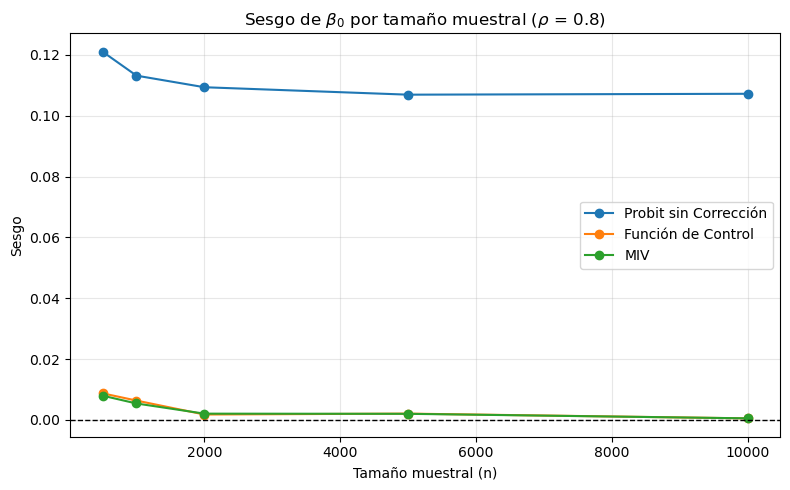

In [88]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

mc_tmp = resumen_mc[resumen_mc['rho'] == rho_fijo]
cf_tmp = resumen_cf[resumen_cf['rho'] == rho_fijo]
miv_tmp = resumen_miv[resumen_miv['rho'] == rho_fijo]

plt.plot(mc_tmp['n'], mc_tmp['sesgo_beta0'], marker='o', label='Probit sin Corrección')
plt.plot(cf_tmp['n'], cf_tmp['sesgo_beta0_cf'], marker='o', label='Función de Control')
plt.plot(miv_tmp['n'], miv_tmp['sesgo_beta0_miv'], marker='o', label='MIV')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel("Tamaño muestral (n)")
plt.ylabel("Sesgo")
plt.title(f"Sesgo de $\\beta_0$ por tamaño muestral ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("sesgo_beta0_por_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [90]:
# GRÁFICO 2: MSE de β0 vs tamaño muestral

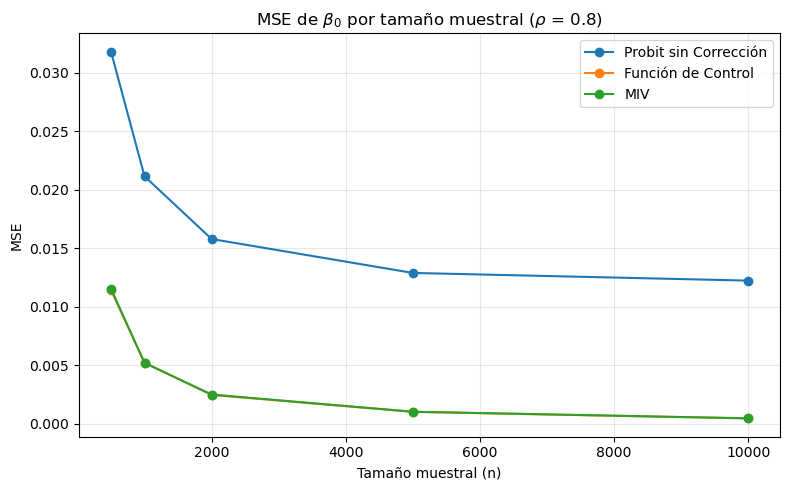

In [91]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

mc_tmp = resumen_mc[resumen_mc['rho'] == rho_fijo]
cf_tmp = resumen_cf[resumen_cf['rho'] == rho_fijo]
miv_tmp = resumen_miv[resumen_miv['rho'] == rho_fijo]

plt.plot(mc_tmp['n'], mc_tmp['mse_beta0'], marker='o', label='Probit sin Corrección')
plt.plot(cf_tmp['n'], cf_tmp['mse_beta0_cf'], marker='o', label='Función de Control')
plt.plot(miv_tmp['n'], miv_tmp['mse_beta0_miv'], marker='o', label='MIV')

plt.grid(True, alpha=0.3)
plt.xlabel("Tamaño muestral (n)")
plt.ylabel("MSE")
plt.title(f"MSE de $\\beta_0$ por tamaño muestral ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("mse_beta0_por_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [93]:
# GRÁFICO 3: Varianza de β0 vs tamaño muestral

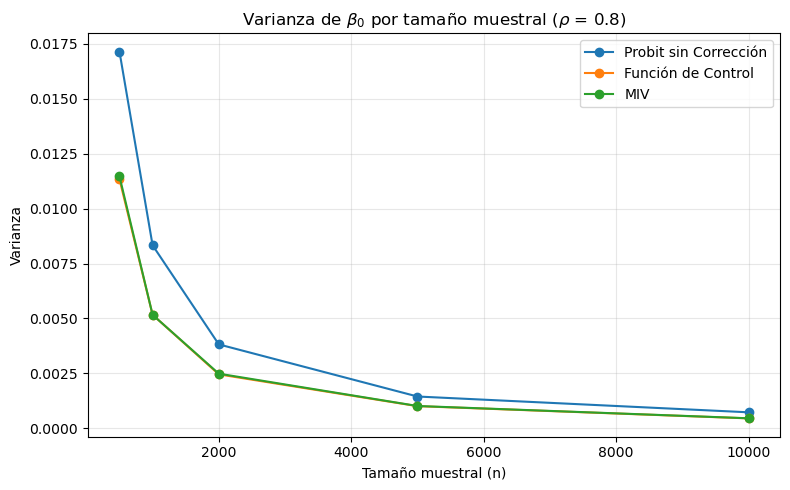

In [94]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

mc_tmp = resumen_mc[resumen_mc['rho'] == rho_fijo]
cf_tmp = resumen_cf[resumen_cf['rho'] == rho_fijo]
miv_tmp = resumen_miv[resumen_miv['rho'] == rho_fijo]

plt.plot(mc_tmp['n'], mc_tmp['beta0_varianza'], marker='o', label='Probit sin Corrección')
plt.plot(cf_tmp['n'], cf_tmp['var_beta0_cf'], marker='o', label='Función de Control')
plt.plot(miv_tmp['n'], miv_tmp['var_beta0_miv'], marker='o', label='MIV')

plt.grid(True, alpha=0.3)
plt.xlabel("Tamaño muestral (n)")
plt.ylabel("Varianza")
plt.title(f"Varianza de $\\beta_0$ por tamaño muestral ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("var_beta0_por_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [96]:
# GRÁFICO 4: Sesgo de β0 vs fuerza instrumental

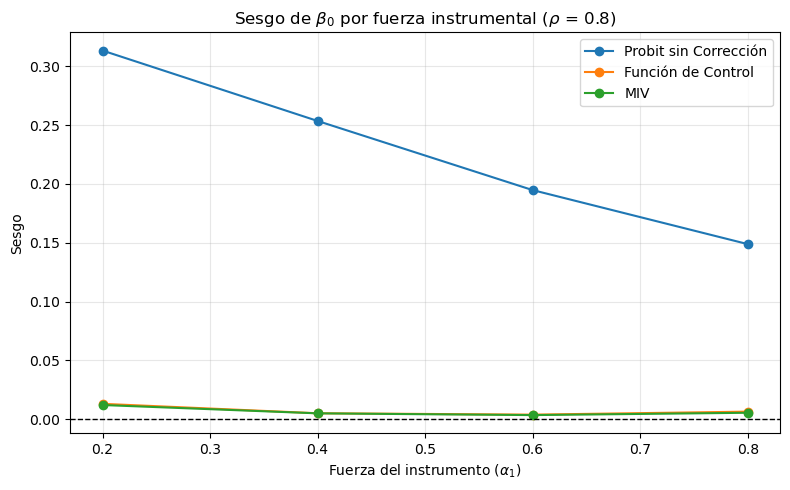

In [97]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

mc_tmp = resumen_mc_alpha[resumen_mc_alpha['rho'] == rho_fijo]
cf_tmp = resumen_cf_alpha[resumen_cf_alpha['rho'] == rho_fijo]
miv_tmp = resumen_miv_alpha[resumen_miv_alpha['rho'] == rho_fijo]

plt.plot(mc_tmp['alpha1'], mc_tmp['sesgo_beta0'], marker='o', label='Probit sin Corrección')
plt.plot(cf_tmp['alpha1'], cf_tmp['sesgo_beta0_cf'], marker='o', label='Función de Control')
plt.plot(miv_tmp['alpha1'], miv_tmp['sesgo_beta0_miv'], marker='o', label='MIV')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel("Fuerza del instrumento ($\\alpha_1$)")
plt.ylabel("Sesgo")
plt.title(f"Sesgo de $\\beta_0$ por fuerza instrumental ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("sesgo_beta0_por_alpha1.png", dpi=300, bbox_inches='tight')
plt.show()

In [99]:
#GRÁFICO 5: MSE de β0 vs fuerza instrumental

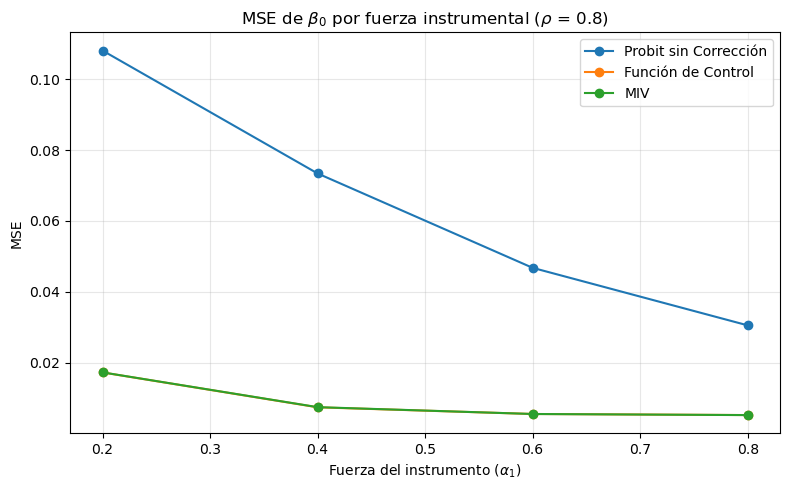

In [100]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

mc_tmp = resumen_mc_alpha[resumen_mc_alpha['rho'] == rho_fijo]
cf_tmp = resumen_cf_alpha[resumen_cf_alpha['rho'] == rho_fijo]
miv_tmp = resumen_miv_alpha[resumen_miv_alpha['rho'] == rho_fijo]

plt.plot(mc_tmp['alpha1'], mc_tmp['mse_beta0'], marker='o', label='Probit sin Corrección')
plt.plot(cf_tmp['alpha1'], cf_tmp['mse_beta0_cf'], marker='o', label='Función de Control')
plt.plot(miv_tmp['alpha1'], miv_tmp['mse_beta0_miv'], marker='o', label='MIV')

plt.grid(True, alpha=0.3)
plt.xlabel("Fuerza del instrumento ($\\alpha_1$)")
plt.ylabel("MSE")
plt.title(f"MSE de $\\beta_0$ por fuerza instrumental ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("mse_beta0_por_alpha1.png", dpi=300, bbox_inches='tight')
plt.show()

In [102]:
# GRÁFICO 6: Varianza de β0 vs fuerza instrumental

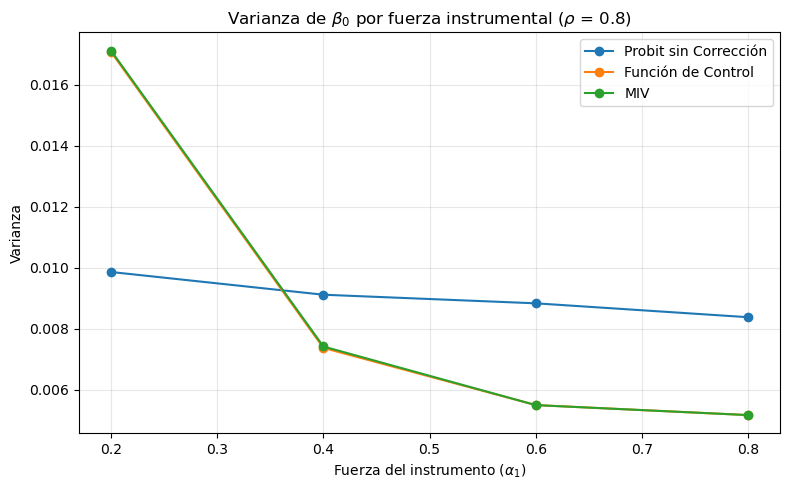

In [103]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

mc_tmp = resumen_mc_alpha[resumen_mc_alpha['rho'] == rho_fijo]
cf_tmp = resumen_cf_alpha[resumen_cf_alpha['rho'] == rho_fijo]
miv_tmp = resumen_miv_alpha[resumen_miv_alpha['rho'] == rho_fijo]

plt.plot(mc_tmp['alpha1'], mc_tmp['beta0_varianza'], marker='o', label='Probit sin Corrección')
plt.plot(cf_tmp['alpha1'], cf_tmp['var_beta0_cf'], marker='o', label='Función de Control')
plt.plot(miv_tmp['alpha1'], miv_tmp['var_beta0_miv'], marker='o', label='MIV')

plt.grid(True, alpha=0.3)
plt.xlabel("Fuerza del instrumento ($\\alpha_1$)")
plt.ylabel("Varianza")
plt.title(f"Varianza de $\\beta_0$ por fuerza instrumental ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("var_beta0_por_alpha1.png", dpi=300, bbox_inches='tight')
plt.show()

In [105]:
# GRÁFICO 7: Sesgo de β1 vs tamaño muestral

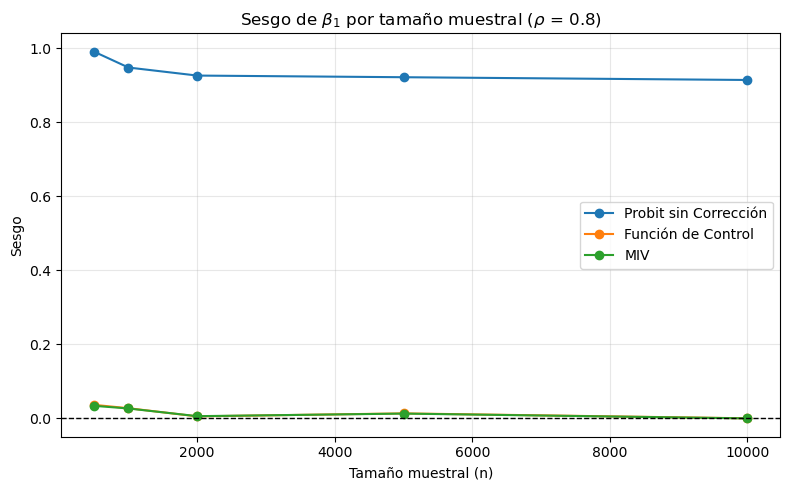

In [106]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

mc_tmp = resumen_mc[resumen_mc['rho'] == rho_fijo]
cf_tmp = resumen_cf[resumen_cf['rho'] == rho_fijo]
miv_tmp = resumen_miv[resumen_miv['rho'] == rho_fijo]

plt.plot(mc_tmp['n'], mc_tmp['sesgo_beta1'], marker='o', label='Probit sin Corrección')
plt.plot(cf_tmp['n'], cf_tmp['sesgo_beta1_cf'], marker='o', label='Función de Control')
plt.plot(miv_tmp['n'], miv_tmp['sesgo_beta1_miv'], marker='o', label='MIV')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel("Tamaño muestral (n)")
plt.ylabel("Sesgo")
plt.title(f"Sesgo de $\\beta_1$ por tamaño muestral ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("sesgo_beta1_por_n.png", dpi=300, bbox_inches='tight')
plt.show()

In [108]:
# GRÁFICO 8: ρ estimado vs fuerza instrumental

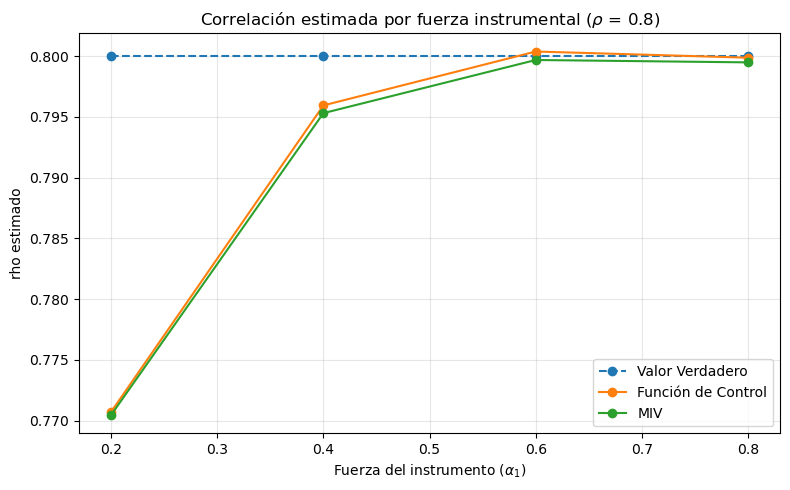

In [109]:
rho_fijo = 0.8

plt.figure(figsize=(8,5))

cf_tmp = resumen_cf_alpha[resumen_cf_alpha['rho'] == rho_fijo]
miv_tmp = resumen_miv_alpha[resumen_miv_alpha['rho'] == rho_fijo]

plt.plot(cf_tmp['alpha1'], [rho_fijo]*len(cf_tmp), marker='o', linestyle='--', label='Valor Verdadero')
plt.plot(cf_tmp['alpha1'], cf_tmp['rho_cf_promedio'], marker='o', label='Función de Control')
plt.plot(miv_tmp['alpha1'], miv_tmp['rho_miv_promedio'], marker='o', label='MIV')

plt.grid(True, alpha=0.3)
plt.xlabel("Fuerza del instrumento ($\\alpha_1$)")
plt.ylabel("rho estimado")
plt.title(f"Correlación estimada por fuerza instrumental ($\\rho$ = {rho_fijo})")
plt.legend()
plt.tight_layout()
plt.savefig("rho_estimado_por_alpha1.png", dpi=300, bbox_inches='tight')
plt.show()

In [111]:
#GRÁFICO 9: VARIANZA DE BETA 0 POR RHO

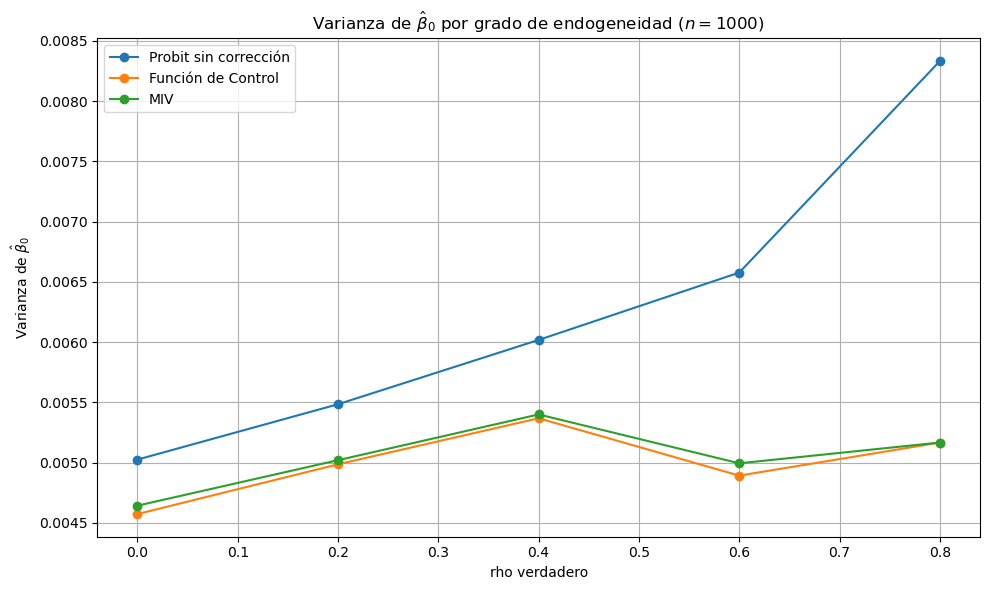

In [112]:
n_ref = 1000

mc_rho  = resumen_mc[resumen_mc["n"] == n_ref].sort_values("rho")
cf_rho  = resumen_cf[resumen_cf["n"] == n_ref].sort_values("rho")
miv_rho = resumen_miv[resumen_miv["n"] == n_ref].sort_values("rho")

plt.figure(figsize=(10,6))

# Probit sin corrección
plt.plot(mc_rho["rho"], mc_rho["beta0_varianza"],
         marker="o", label="Probit sin corrección")

# Control Function
plt.plot(cf_rho["rho"], cf_rho["var_beta0_cf"],
         marker="o", label="Función de Control")

# MIV
plt.plot(miv_rho["rho"], miv_rho["var_beta0_miv"],
         marker="o", label="MIV")

plt.grid(True)
plt.xlabel(r"rho verdadero")
plt.ylabel(r"Varianza de $\hat{\beta}_0$")
plt.title(r"Varianza de $\hat{\beta}_0$ por grado de endogeneidad ($n = 1000$)")
plt.legend()
plt.tight_layout()
plt.savefig("varianza_beta0_por_rho.png", dpi=300, bbox_inches="tight")
plt.savefig("varianza_beta0_por_rho.pdf", bbox_inches="tight")

plt.show()

In [114]:
# Gráfico 10: SESGO DE beta0 POR RHO

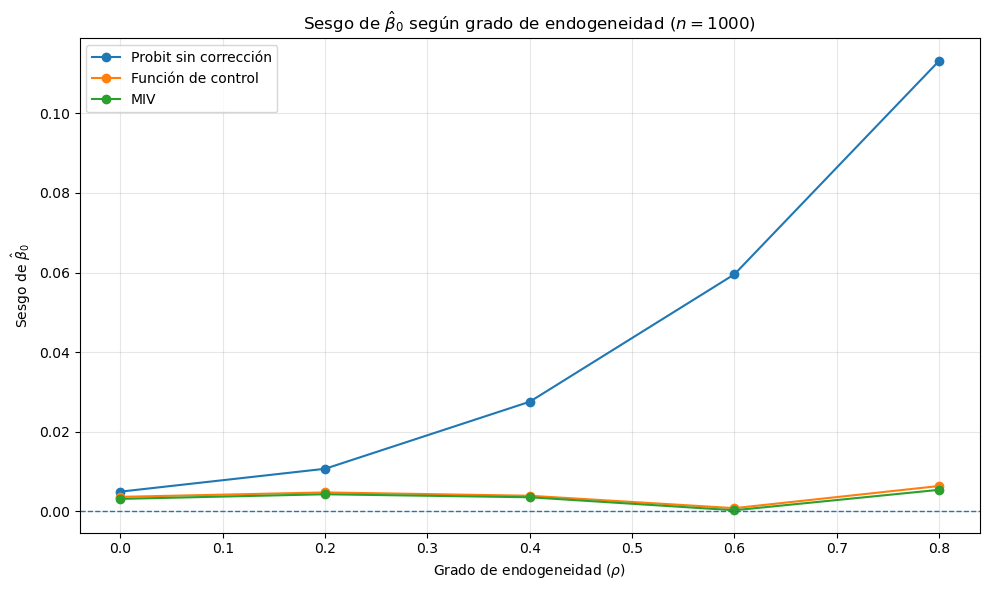

In [115]:
# Tamaño muestral de referencia
n_ref = 1000

# Filtrar resultados por n = 1000
mc_rho  = resumen_mc[resumen_mc["n"] == n_ref].sort_values("rho")
cf_rho  = resumen_cf[resumen_cf["n"] == n_ref].sort_values("rho")
miv_rho = resumen_miv[resumen_miv["n"] == n_ref].sort_values("rho")

plt.figure(figsize=(10,6))

plt.plot(mc_rho["rho"], mc_rho["sesgo_beta0"],
         marker="o", label="Probit sin corrección")

plt.plot(cf_rho["rho"], cf_rho["sesgo_beta0_cf"],
         marker="o", label="Función de control")

plt.plot(miv_rho["rho"], miv_rho["sesgo_beta0_miv"],
         marker="o", label="MIV")

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel(r"Grado de endogeneidad ($\rho$)")
plt.ylabel(r"Sesgo de $\hat{\beta}_0$")
plt.title(r"Sesgo de $\hat{\beta}_0$ según grado de endogeneidad ($n=1000$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("sesgo_beta0_por_rho.png", dpi=300, bbox_inches="tight")
plt.show()

In [118]:
#GRÁFICO 11: MSE DE beta0 POR RHO

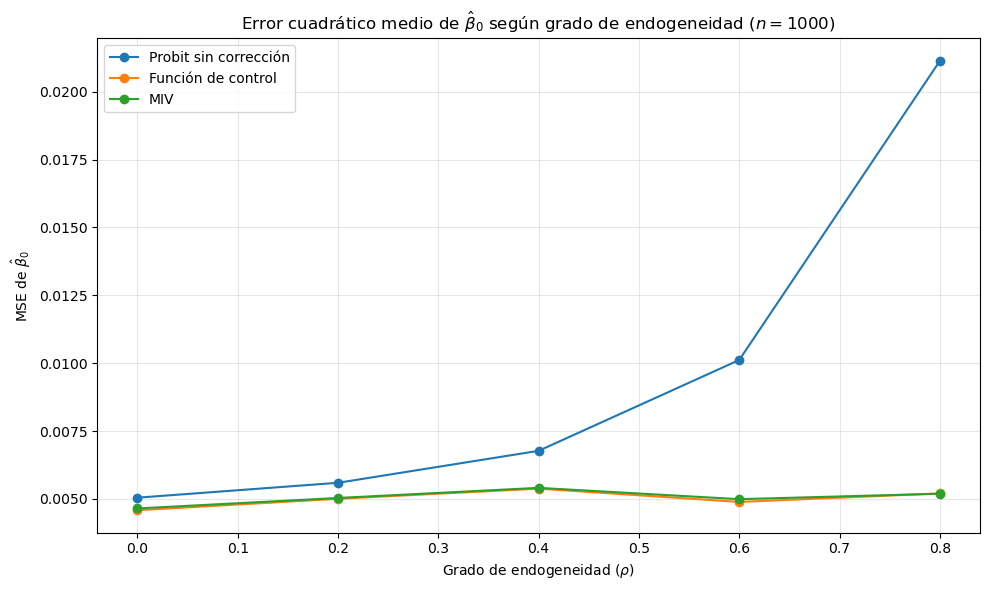

In [119]:
n_ref = 1000

# Filtrar resultados por n = 1000
mc_rho  = resumen_mc[resumen_mc["n"] == n_ref].sort_values("rho")
cf_rho  = resumen_cf[resumen_cf["n"] == n_ref].sort_values("rho")
miv_rho = resumen_miv[resumen_miv["n"] == n_ref].sort_values("rho")
plt.figure(figsize=(10,6))

plt.plot(mc_rho["rho"], mc_rho["mse_beta0"],
         marker="o", label="Probit sin corrección")

plt.plot(cf_rho["rho"], cf_rho["mse_beta0_cf"],
         marker="o", label="Función de control")

plt.plot(miv_rho["rho"], miv_rho["mse_beta0_miv"],
         marker="o", label="MIV")

plt.xlabel(r"Grado de endogeneidad ($\rho$)")
plt.ylabel(r"MSE de $\hat{\beta}_0$")
plt.title(r"Error cuadrático medio de $\hat{\beta}_0$ según grado de endogeneidad ($n=1000$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("mse_beta0_por_rho.png", dpi=300, bbox_inches="tight")
plt.show()

In [122]:
# ==========================================
# APLICACIÓN EMPÍRICA INSOCIAL
# ==========================================

In [123]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Cargar base
df = pd.read_excel("all_data.xlsx")

# Revisar
print(df.head())
print(df.info())
print(df.isna().sum())

   lnsocial  we_fee  y
0  0.000000  1000.0  1
1  0.000000   160.0  1
2  0.000000   200.0  0
3  7.600903   200.0  1
4  0.000000  1500.0  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37794 entries, 0 to 37793
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   lnsocial  37794 non-null  float64
 1   we_fee    37794 non-null  float64
 2   y         37794 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 885.9 KB
None
lnsocial    0
we_fee      0
y           0
dtype: int64


In [124]:
# Variables de interés
y_var = 'y'
x_var = 'lnsocial'
z_var = 'we_fee'

# Dejar solo variables necesarias
data = df[[y_var, x_var, z_var]].copy()

# Eliminar faltantes si existieran
data = data.dropna().copy()

#data.isnull().mean() 

# Asegurar tipos numéricos
data[y_var] = pd.to_numeric(data[y_var], errors='coerce')
data[x_var] = pd.to_numeric(data[x_var], errors='coerce')
data[z_var] = pd.to_numeric(data[z_var], errors='coerce')

data = data.dropna().copy()

print("Número de observaciones:", len(data))
print(data.describe())

Número de observaciones: 37794
                  y      lnsocial        we_fee
count  37794.000000  37794.000000  37794.000000
mean       0.162804      2.765009    342.733784
std        0.369191      3.655016    579.649166
min        0.000000      0.000000      0.000000
25%        0.000000      0.000000    100.000000
50%        0.000000      0.000000    200.000000
75%        0.000000      6.907755    400.000000
max        1.000000     13.500800  25000.000000


In [125]:
tabla_descriptiva = data[[y_var, x_var, z_var]].agg([
    'count', 'mean', 'std', 'min', 'median', 'max'
]).T

tabla_descriptiva = tabla_descriptiva.rename(columns={
    'count': 'N',
    'mean': 'Media',
    'std': 'DesvStd',
    'min': 'Min',
    'median': 'Mediana',
    'max': 'Max'
})

tabla_descriptiva

,N,Media,DesvStd,Min,Mediana,Max
y,37794.0,0.162804,0.369191,0.0,0.0,1.0000
lnsocial,37794.0,2.765009,3.655016,0.0,0.0,13.5008
we_fee,37794.0,342.733784,579.649166,0.0,200.0,25000.0000


In [126]:
data[["lnsocial","we_fee"]].corr()

,lnsocial,we_fee
lnsocial,1.000000,0.043526
we_fee,0.043526,1.000000


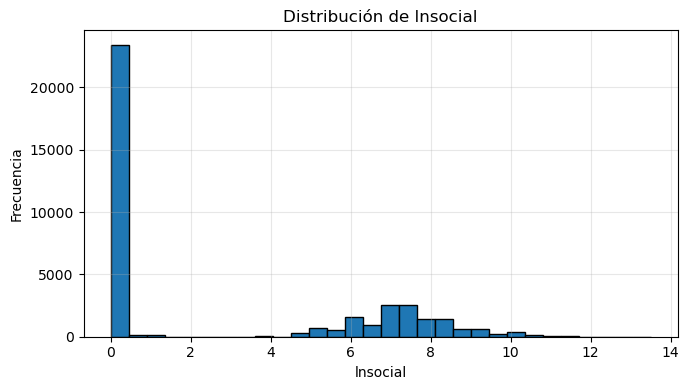

In [127]:
plt.figure(figsize=(7,4))
plt.hist(data[x_var], bins=30, edgecolor='black')
plt.xlabel('lnsocial')
plt.ylabel('Frecuencia')
plt.title('Distribución de lnsocial')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Distribucion_insocial.png", dpi=300, bbox_inches="tight")
plt.show()

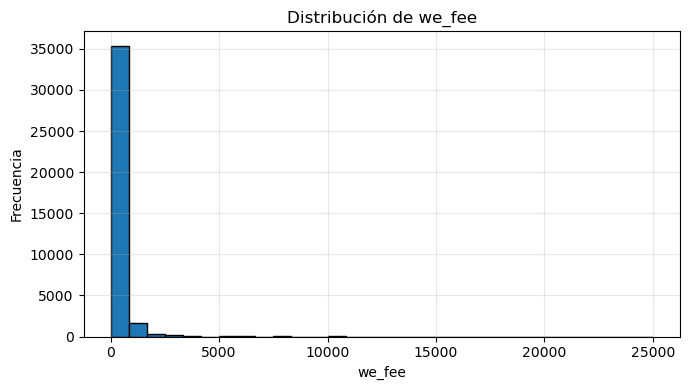

In [128]:
plt.figure(figsize=(7,4))
plt.hist(data[z_var], bins=30, edgecolor='black')
plt.xlabel('we_fee')
plt.ylabel('Frecuencia')
plt.title('Distribución de we_fee')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Distribucion_we_fee.png", dpi=300, bbox_inches="tight")
plt.show()

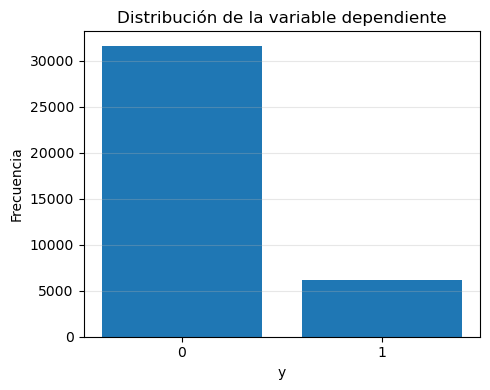

Proporción y=1: 0.16280361962216225


In [129]:
conteo_y = data[y_var].value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(conteo_y.index.astype(str), conteo_y.values)
plt.xlabel('y')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable dependiente')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("Distribucion_var_dep.png", dpi=300, bbox_inches="tight")
plt.show()

print("Proporción y=1:", data[y_var].mean())

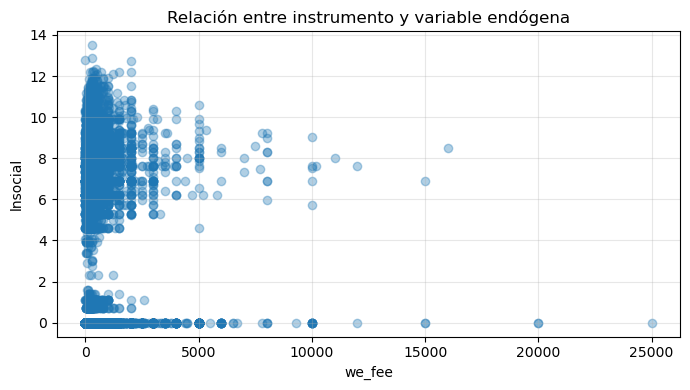

In [130]:
plt.figure(figsize=(7,4))
plt.scatter(data[z_var], data[x_var], alpha=0.35)
plt.xlabel('we_fee')
plt.ylabel('lnsocial')
plt.title('Relación entre instrumento y variable endógena')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Relacion_inst_var_end.png", dpi=300, bbox_inches="tight")
plt.show()

In [131]:
X_1 = sm.add_constant(data[z_var])
first_stage = sm.OLS(data[x_var], X_1).fit(cov_type='HC1')

print(first_stage.summary())

                            OLS Regression Results                            
Dep. Variable:               lnsocial   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     41.55
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           1.16e-10
Time:                        00:22:36   Log-Likelihood:            -1.0258e+05
No. Observations:               37794   AIC:                         2.052e+05
Df Residuals:                   37792   BIC:                         2.052e+05
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6709      0.023    115.490      0.0

In [132]:
coef_primera = first_stage.params
se_primera = first_stage.bse
pval_primera = first_stage.pvalues
r2_primera = first_stage.rsquared

print("Coeficiente we_fee:", coef_primera[z_var])
print("EE robusto:", se_primera[z_var])
print("p-valor:", pval_primera[z_var])
print("R2:", r2_primera)

Coeficiente we_fee: 0.000274455865325187
EE robusto: 4.2579959790679313e-05
p-valor: 1.1509982456699073e-10
R2: 0.0018945100357609101


In [135]:
#Probit sin correción

In [136]:
X_probit = sm.add_constant(data[x_var])
probit_sin_correccion = sm.Probit(data[y_var], X_probit).fit(disp=False)

print(probit_sin_correccion.summary())

                          Probit Regression Results                           
Dep. Variable:                      y   No. Observations:                37794
Model:                         Probit   Df Residuals:                    37792
Method:                           MLE   Df Model:                            1
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                0.009999
Time:                        00:22:36   Log-Likelihood:                -16624.
converged:                       True   LL-Null:                       -16791.
Covariance Type:            nonrobust   LLR p-value:                 5.273e-75
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0965      0.010   -108.863      0.000      -1.116      -1.077
lnsocial       0.0377      0.002     18.375      0.000       0.034       0.042


In [137]:
marginal_sin_correccion = probit_sin_correccion.get_margeff()
print(marginal_sin_correccion.summary())

       Probit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
lnsocial       0.0092      0.000     18.485      0.000       0.008       0.010


In [140]:
#Control Function

In [141]:
data['v_hat'] = first_stage.resid

In [142]:
X_cf = sm.add_constant(data[[x_var, 'v_hat']])
probit_cf = sm.Probit(data[y_var], X_cf).fit(disp=False)

print(probit_cf.summary())

                          Probit Regression Results                           
Dep. Variable:                      y   No. Observations:                37794
Model:                         Probit   Df Residuals:                    37791
Method:                           MLE   Df Model:                            2
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                 0.02937
Time:                        00:22:36   Log-Likelihood:                -16298.
converged:                       True   LL-Null:                       -16791.
Covariance Type:            nonrobust   LLR p-value:                6.307e-215
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2059      0.123    -34.239      0.000      -4.447      -3.965
lnsocial       1.1576      0.044     26.250      0.000       1.071       1.244
v_hat         -1.1217      0.044    -25.427      0.0

In [143]:
beta0_tilde = probit_cf.params['const']
beta1_tilde = probit_cf.params[x_var]
rho_tilde = probit_cf.params['v_hat']

rho_hat_cf = rho_tilde / np.sqrt(1 + rho_tilde**2)
factor_escala = np.sqrt(1 - rho_hat_cf**2)

beta0_cf = beta0_tilde * factor_escala
beta1_cf = beta1_tilde * factor_escala

print("Resultados CF ajustados por escala")
print("beta0_cf =", beta0_cf)
print("beta1_cf =", beta1_cf)
print("rho_cf =", rho_hat_cf)

Resultados CF ajustados por escala
beta0_cf = -2.7988366622919068
beta1_cf = 0.7703210290987312
rho_cf = -0.7464329987572752


In [144]:
print("Coeficiente v_hat:", probit_cf.params['v_hat'])
print("p-valor v_hat:", probit_cf.pvalues['v_hat'])

Coeficiente v_hat: -1.1216787673772373
p-valor v_hat: 1.274218299624575e-142


In [145]:
marginal_cf = probit_cf.get_margeff()
print(marginal_cf.summary())

       Probit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
lnsocial       0.2760      0.010     26.639      0.000       0.256       0.296
v_hat         -0.2674      0.010    -25.782      0.000      -0.288      -0.247


In [148]:
#MIV

In [149]:
x_emp = data[x_var].to_numpy()
y_emp = data[y_var].to_numpy()
z_emp = data[z_var].to_numpy()

n = len(data)

res_miv_emp = estimar_miv(x_emp, y_emp, z_emp)
res_miv_emp

{'beta0_miv': -2.8527031489738413,
 'beta1_miv': 0.806980069443966,
 'rho_miv': -0.7845009584465258,
 'gamma0_hat': -1.2212733071325572,
 'gamma1_hat': 0.036249170049147336,
 'gamma2_hat': 0.0003472041685341509,
 'alpha0_hat': 2.6709436562100692,
 'alpha1_hat': 0.000274455865325187,
 'success': True,
 'cost': 2.6759157126797047e-29,
 'message': '`gtol` termination condition is satisfied.'}

In [150]:
B = 500   # puedes partir con 200 para probar; luego subir a 500 o 1000

resultados_bootstrap_miv = []

np.random.seed(123)

for b in range(B):
    idx = np.random.choice(np.arange(n), size=n, replace=True)

    x_b = x_emp[idx]
    y_b = y_emp[idx]
    z_b = z_emp[idx]

    try:
        res_b = estimar_miv(x_b, y_b, z_b)

        resultados_bootstrap_miv.append({
            'boot': b,
            'beta0_miv': res_b['beta0_miv'],
            'beta1_miv': res_b['beta1_miv'],
            'rho_miv': res_b['rho_miv'],
            'success': res_b['success']
        })

    except Exception:
        resultados_bootstrap_miv.append({
            'boot': b,
            'beta0_miv': np.nan,
            'beta1_miv': np.nan,
            'rho_miv': np.nan,
            'success': False
        })

In [151]:
tabla_bootstrap_miv = pd.DataFrame(resultados_bootstrap_miv)

tabla_bootstrap_miv_ok = tabla_bootstrap_miv[
    (tabla_bootstrap_miv['success'] == True)
].dropna().copy()

print("Bootstrap exitosos:", len(tabla_bootstrap_miv_ok), "de", B)
tabla_bootstrap_miv_ok.head()

Bootstrap exitosos: 500 de 500


,boot,beta0_miv,beta1_miv,rho_miv,success
0,0,-2.918708,0.865990,-0.848278,True
1,1,-2.946521,0.898116,-0.882282,True
2,2,-2.882596,0.822075,-0.801947,True
3,3,-2.803450,0.777295,-0.752188,True
4,4,-2.810833,0.790330,-0.767547,True


In [152]:
se_beta0_boot = tabla_bootstrap_miv_ok['beta0_miv'].std(ddof=1)
se_beta1_boot = tabla_bootstrap_miv_ok['beta1_miv'].std(ddof=1)
se_rho_boot   = tabla_bootstrap_miv_ok['rho_miv'].std(ddof=1)

print("EE bootstrap beta0:", se_beta0_boot)
print("EE bootstrap beta1:", se_beta1_boot)
print("EE bootstrap rho:", se_rho_boot)

EE bootstrap beta0: 0.06176189733756739
EE bootstrap beta1: 0.041725813476901824
EE bootstrap rho: 0.043722738790228005


In [153]:
tabla_miv_empirico = pd.DataFrame({
    'Parametro': ['beta0_miv', 'beta1_miv', 'rho_miv'],
    'Estimacion': [
        res_miv_emp['beta0_miv'],
        res_miv_emp['beta1_miv'],
        res_miv_emp['rho_miv']
    ],
    'EE_bootstrap': [
        se_beta0_boot,
        se_beta1_boot,
        se_rho_boot
    ]
})

tabla_miv_empirico

,Parametro,Estimacion,EE_bootstrap
0,beta0_miv,-2.852703,0.061762
1,beta1_miv,0.806980,0.041726
2,rho_miv,-0.784501,0.043723


In [154]:
ic_beta0 = tabla_bootstrap_miv_ok['beta0_miv'].quantile([0.025, 0.975])
ic_beta1 = tabla_bootstrap_miv_ok['beta1_miv'].quantile([0.025, 0.975])
ic_rho   = tabla_bootstrap_miv_ok['rho_miv'].quantile([0.025, 0.975])

print("IC beta0:")
print(ic_beta0)

print("\nIC beta1:")
print(ic_beta1)

print("\nIC rho:")
print(ic_rho)

IC beta0:
0.025   -2.954132
0.975   -2.715895
Name: beta0_miv, dtype: float64

IC beta1:
0.025    0.720368
0.975    0.883255
Name: beta1_miv, dtype: float64

IC rho:
0.025   -0.865485
0.975   -0.694691
Name: rho_miv, dtype: float64


In [156]:
#Tabla Conjunta

In [157]:
tabla_resultados_empiricos = pd.DataFrame({
    'Metodo': ['Primera etapa', 'Probit Sin Correccion', 'Control Function', 'MIV'],
    'Intercepto': [
        first_stage.params['const'],
        probit_sin_correccion.params['const'],
        beta0_cf,
        res_miv_emp['beta0_miv']
    ],
    'Coef_variable_principal': [
        first_stage.params['we_fee'],
        probit_sin_correccion.params['lnsocial'],
        beta1_cf,
        res_miv_emp['beta1_miv']
    ],
    'Parametro_endogeneidad': [
        np.nan,
        np.nan,
        rho_hat_cf,
        res_miv_emp['rho_miv']
    ],
    'EE_intercepto': [
        first_stage.bse['const'],
        probit_sin_correccion.bse['const'],
        np.nan,
        se_beta0_boot
    ],
    'EE_variable_principal': [
        first_stage.bse['we_fee'],
        probit_sin_correccion.bse['lnsocial'],
        np.nan,
        se_beta1_boot
    ],
    'EE_endogeneidad': [
        np.nan,
        np.nan,
        np.nan,
        se_rho_boot
    ]
})

tabla_resultados_empiricos

,Metodo,Intercepto,Coef_variable_principal,Parametro_endogeneidad,EE_intercepto,EE_variable_principal,EE_endogeneidad
0,Primera etapa,2.670944,0.000274,NaN,0.023127,0.000043,NaN
1,Probit Sin Correccion,-1.096527,0.037715,NaN,0.010073,0.002052,NaN
2,Control Function,-2.798837,0.770321,-0.746433,NaN,NaN,NaN
3,MIV,-2.852703,0.806980,-0.784501,0.061762,0.041726,0.043723


In [158]:
tabla_resultados_empiricos.to_csv("tabla_resultados_empiricos.csv", index=False)

In [162]:
tabla_descriptiva_empirica = data[[y_var, x_var, z_var]].agg([
    'count', 'mean', 'std', 'min', 'median', 'max'
]).T

tabla_descriptiva_empirica = tabla_descriptiva_empirica.rename(columns={
    'count': 'N',
    'mean': 'Media',
    'std': 'Desv. estándar',
    'min': 'Mínimo',
    'median': 'Mediana',
    'max': 'Máximo'
})

tabla_descriptiva_empirica.to_csv("tabla_descriptiva_empirica.csv", index=True)
tabla_descriptiva_empirica.to_latex(
    "tabla_descriptiva_empirica.tex",
    float_format="%.4f",
    decimal=","
)

tabla_descriptiva_empirica

,N,Media,Desv. estándar,Mínimo,Mediana,Máximo
y,37794.0,0.162804,0.369191,0.0,0.0,1.0000
lnsocial,37794.0,2.765009,3.655016,0.0,0.0,13.5008
we_fee,37794.0,342.733784,579.649166,0.0,200.0,25000.0000


In [165]:
corr_lnsocial_wefee = data[[x_var, z_var]].corr().loc[x_var, z_var]

tabla_primera_etapa = pd.DataFrame({
    'Indicador': [
        'N',
        'Corr(lnsocial, we_fee)',
        'Coeficiente we_fee',
        'EE robusto',
        'Estadístico z',
        'p-valor',
        'R2',
        'F primera etapa'
    ],
    'Valor': [
        len(data),
        corr_lnsocial_wefee,
        first_stage.params[z_var],
        first_stage.bse[z_var],
        first_stage.tvalues[z_var],
        first_stage.pvalues[z_var],
        first_stage.rsquared,
        float(first_stage.fvalue)
    ]
})

tabla_primera_etapa.to_csv("tabla_primera_etapa.csv", index=False)
tabla_primera_etapa.to_latex(
    "tabla_primera_etapa.tex",
    index=False,
    float_format="%.6f",
    decimal=","
)

tabla_primera_etapa

,Indicador,Valor
0,N,3.779400e+04
1,"Corr(lnsocial, we_fee)",4.352597e-02
2,Coeficiente we_fee,2.744559e-04
3,EE robusto,4.257996e-05
4,Estadístico z,6.445658e+00
5,p-valor,1.150998e-10
6,R2,1.894510e-03
7,F primera etapa,4.154651e+01


In [168]:
B_cf = 500
resultados_bootstrap_cf = []

np.random.seed(123)

for b in range(B_cf):
    idx = np.random.choice(np.arange(len(data)), size=len(data), replace=True)
    data_b = data.iloc[idx].copy()

    try:
        # Primera etapa bootstrap
        X1_b = sm.add_constant(data_b[z_var])
        fs_b = sm.OLS(data_b[x_var], X1_b).fit()

        data_b['v_hat_b'] = fs_b.resid

        # Segunda etapa Probit
        X_cf_b = sm.add_constant(data_b[[x_var, 'v_hat_b']])
        probit_cf_b = sm.Probit(data_b[y_var], X_cf_b).fit(disp=False)

        beta0_tilde_b = probit_cf_b.params['const']
        beta1_tilde_b = probit_cf_b.params[x_var]
        rho_tilde_b = probit_cf_b.params['v_hat_b']

        rho_hat_b = rho_tilde_b / np.sqrt(1 + rho_tilde_b**2)
        factor_b = np.sqrt(1 - rho_hat_b**2)

        beta0_cf_b = beta0_tilde_b * factor_b
        beta1_cf_b = beta1_tilde_b * factor_b

        resultados_bootstrap_cf.append({
            'boot': b,
            'beta0_cf': beta0_cf_b,
            'beta1_cf': beta1_cf_b,
            'rho_cf': rho_hat_b,
            'success': True
        })

    except Exception:
        resultados_bootstrap_cf.append({
            'boot': b,
            'beta0_cf': np.nan,
            'beta1_cf': np.nan,
            'rho_cf': np.nan,
            'success': False
        })

tabla_bootstrap_cf = pd.DataFrame(resultados_bootstrap_cf)

tabla_bootstrap_cf_ok = tabla_bootstrap_cf[
    tabla_bootstrap_cf['success'] == True
].dropna().copy()

se_beta0_cf_boot = tabla_bootstrap_cf_ok['beta0_cf'].std(ddof=1)
se_beta1_cf_boot = tabla_bootstrap_cf_ok['beta1_cf'].std(ddof=1)
se_rho_cf_boot = tabla_bootstrap_cf_ok['rho_cf'].std(ddof=1)

print("Bootstrap CF exitosos:", len(tabla_bootstrap_cf_ok), "de", B_cf)
print("EE bootstrap beta0 CF:", se_beta0_cf_boot)
print("EE bootstrap beta1 CF:", se_beta1_cf_boot)
print("EE bootstrap rho CF:", se_rho_cf_boot)

Bootstrap CF exitosos: 500 de 500
EE bootstrap beta0 CF: 0.0719773749215068
EE bootstrap beta1 CF: 0.04478548563256746
EE bootstrap rho CF: 0.04668051124307846


In [171]:
def pval_from_est_se(est, se):
    if pd.isna(est) or pd.isna(se) or se == 0:
        return np.nan
    z = est / se
    return 2 * (1 - norm.cdf(abs(z)))

tabla_resultados_empiricos_final = pd.DataFrame({
    'Método': [
        'Probit sin corrección',
        'Función de control',
        'MIV'
    ],
    'Intercepto': [
        probit_sin_correccion.params['const'],
        beta0_cf,
        res_miv_emp['beta0_miv']
    ],
    'EE Intercepto': [
        probit_sin_correccion.bse['const'],
        se_beta0_cf_boot,
        se_beta0_boot
    ],
    'Coef. lnsocial': [
        probit_sin_correccion.params[x_var],
        beta1_cf,
        res_miv_emp['beta1_miv']
    ],
    'EE Coef. lnsocial': [
        probit_sin_correccion.bse[x_var],
        se_beta1_cf_boot,
        se_beta1_boot
    ],
    'Parámetro endogeneidad': [
        np.nan,
        rho_hat_cf,
        res_miv_emp['rho_miv']
    ],
    'EE parámetro endogeneidad': [
        np.nan,
        se_rho_cf_boot,
        se_rho_boot
    ]
})

tabla_resultados_empiricos_final['p-valor Intercepto'] = tabla_resultados_empiricos_final.apply(
    lambda row: pval_from_est_se(row['Intercepto'], row['EE Intercepto']),
    axis=1
)

tabla_resultados_empiricos_final['p-valor lnsocial'] = tabla_resultados_empiricos_final.apply(
    lambda row: pval_from_est_se(row['Coef. lnsocial'], row['EE Coef. lnsocial']),
    axis=1
)

tabla_resultados_empiricos_final['p-valor endogeneidad'] = tabla_resultados_empiricos_final.apply(
    lambda row: pval_from_est_se(row['Parámetro endogeneidad'], row['EE parámetro endogeneidad']),
    axis=1
)

tabla_resultados_empiricos_final.to_csv("tabla_resultados_empiricos_final.csv", index=False)
tabla_resultados_empiricos_final.to_latex(
    "tabla_resultados_empiricos_final.tex",
    index=False,
    float_format="%.4f",
    decimal=","
)

tabla_resultados_empiricos_final

,Método,Intercepto,EE Intercepto,Coef. lnsocial,EE Coef. lnsocial,Parámetro endogeneidad,EE parámetro endogeneidad,p-valor Intercepto,p-valor lnsocial,p-valor endogeneidad
0,Probit sin corrección,-1.096527,0.010073,0.037715,0.002052,NaN,NaN,0.0,0.0,NaN
1,Función de control,-2.798837,0.071977,0.770321,0.044785,-0.746433,0.046681,0.0,0.0,0.0
2,MIV,-2.852703,0.061762,0.806980,0.041726,-0.784501,0.043723,0.0,0.0,0.0


In [174]:
tabla_ic_miv = pd.DataFrame({
    'Parámetro': ['beta0_miv', 'beta1_miv', 'rho_miv'],
    'Estimación': [
        res_miv_emp['beta0_miv'],
        res_miv_emp['beta1_miv'],
        res_miv_emp['rho_miv']
    ],
    'EE bootstrap': [
        se_beta0_boot,
        se_beta1_boot,
        se_rho_boot
    ],
    'IC 2.5%': [
        ic_beta0.loc[0.025],
        ic_beta1.loc[0.025],
        ic_rho.loc[0.025]
    ],
    'IC 97.5%': [
        ic_beta0.loc[0.975],
        ic_beta1.loc[0.975],
        ic_rho.loc[0.975]
    ]
})

tabla_ic_miv.to_csv("tabla_ic_miv.csv", index=False)
tabla_ic_miv.to_latex(
    "tabla_ic_miv.tex",
    index=False,
    float_format="%.4f",
    decimal=","
)

tabla_ic_miv

,Parámetro,Estimación,EE bootstrap,IC 2.5%,IC 97.5%
0,beta0_miv,-2.852703,0.061762,-2.954132,-2.715895
1,beta1_miv,0.806980,0.041726,0.720368,0.883255
2,rho_miv,-0.784501,0.043723,-0.865485,-0.694691


In [177]:
def resumen_prediccion_probit(beta0, beta1, x):
    indice = beta0 + beta1 * x
    prob = norm.cdf(indice)
    ame = np.mean(norm.pdf(indice) * beta1)

    return {
        "Probabilidad predicha promedio": np.mean(prob),
        "AME lnsocial": ame,
        "Mín. probabilidad predicha": np.min(prob),
        "Máx. probabilidad predicha": np.max(prob)
    }

tabla_efectos_empiricos = pd.DataFrame([
    {
        "Método": "Probit sin corrección",
        **resumen_prediccion_probit(
            probit_sin_correccion.params["const"],
            probit_sin_correccion.params[x_var],
            data[x_var]
        )
    },
    {
        "Método": "Función de control",
        **resumen_prediccion_probit(
            beta0_cf,
            beta1_cf,
            data[x_var]
        )
    },
    {
        "Método": "MIV",
        **resumen_prediccion_probit(
            res_miv_emp["beta0_miv"],
            res_miv_emp["beta1_miv"],
            data[x_var]
        )
    }
])

tabla_efectos_empiricos.to_csv("tabla_efectos_empiricos.csv", index=False)

tabla_efectos_empiricos.to_latex(
    "tabla_efectos_empiricos.tex",
    index=False,
    float_format="%.4f",
    decimal=","
)

tabla_efectos_empiricos

,Método,Probabilidad predicha promedio,AME lnsocial,Mín. probabilidad predicha,Máx. probabilidad predicha
0,Probit sin corrección,0.162824,0.009190,0.136424,0.278485
1,Función de control,0.368488,0.013407,0.002564,1.000000
2,MIV,0.369851,0.011240,0.002167,1.000000
